# 주택 가격 예측 모델

# 1. 환경 설정 및 라이브러리 임포트

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 통계
from scipy import stats
from scipy.stats import skew, kurtosis

# 전처리
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, RobustScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from scipy.special import boxcox1p
from scipy.stats import boxcox_normmax
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 회귀
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, VotingRegressor, StackingRegressor
from sklearn.tree import DecisionTreeRegressor

# 트리
import xgboost as xgb
import lightgbm as lgb

# 하이퍼파라미터 (optuna 사용)
import optuna
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING)


# 시각화 
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# 기타
pd.set_option('display.max_columns', None)  # 모든 컬럼 표시
pd.set_option('display.max_rows', 100)  # 최대 100행까지 표시
pd.set_option('display.float_format', '{:.4f}'.format)  # 소수점 4자리까지 표시

import warnings
warnings.filterwarnings('ignore')

# 2. 데이터 로드, 기본 정보 확인

In [332]:
train_df = pd.read_csv('./train.csv')
test_df = pd.read_csv('./test.csv')

In [333]:
print(f" train_df.shape: {train_df.shape}")
print(f" test_df.shape: {test_df.shape}")
train_df.head()

 train_df.shape: (1168, 81)
 test_df.shape: (292, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,968,20,RL,NaN,7390,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,NAmes,Norm,Norm,1Fam,1Story,5,7,1955,1955,Hip,CompShg,Wd Sdng,Wd Sdng,BrkFace,151.0000,TA,TA,CBlock,TA,TA,No,ALQ,902,Unf,0,196,1098,GasA,TA,Y,SBrkr,1098,0,0,1098,1,0,1,0,3,1,TA,6,Typ,0,NaN,Attchd,1955.0000,Unf,1,260,TA,TA,Y,0,0,0,0,0,0,NaN,NaN,NaN,0,7,2008,WD,Normal,135000
1,739,90,RL,60.0000,10800,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Edwards,Norm,Norm,Duplex,1Story,5,5,1987,1988,Gable,CompShg,Plywood,Plywood,NaN,0.0000,TA,TA,CBlock,Gd,Gd,Gd,GLQ,1200,Unf,0,0,1200,GasA,TA,Y,SBrkr,1200,0,0,1200,3,0,3,0,3,1,TA,5,Typ,0,NaN,NaN,NaN,NaN,0,0,NaN,NaN,Y,120,0,0,0,0,0,NaN,NaN,NaN,0,3,2009,WD,Alloca,179000
2,696,20,RL,54.0000,13811,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Timber,Norm,Norm,1Fam,1Story,6,6,1987,1987,Gable,CompShg,HdBoard,HdBoard,BrkFace,72.0000,TA,TA,CBlock,Gd,Gd,No,GLQ,980,LwQ,40,92,1112,GasA,Gd,Y,SBrkr,1137,0,0,1137,1,0,2,0,2,1,Gd,5,Typ,1,TA,Attchd,1987.0000,Unf,2,551,TA,TA,Y,125,0,0,0,0,0,NaN,NaN,NaN,0,7,2006,WD,Normal,176000
3,239,20,RL,93.0000,12030,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NridgHt,Norm,Norm,1Fam,1Story,8,5,2007,2007,Hip,CompShg,VinylSd,VinylSd,BrkFace,254.0000,Ex,TA,PConc,Ex,TA,No,Unf,0,Unf,0,1694,1694,GasA,Ex,Y,SBrkr,1694,0,0,1694,0,0,2,0,3,1,Gd,7,Typ,0,NaN,Attchd,2007.0000,Fin,3,818,TA,TA,Y,168,228,0,0,0,0,NaN,NaN,NaN,0,12,2007,New,Partial,318000
4,891,50,RL,60.0000,8064,Pave,NaN,Reg,Lvl,AllPub,Corner,Gtl,NAmes,Artery,Norm,1Fam,1.5Fin,5,7,1949,2006,Gable,CompShg,MetalSd,MetalSd,NaN,0.0000,TA,Gd,CBlock,TA,TA,Mn,Unf,0,Unf,0,672,672,GasA,Ex,Y,SBrkr,672,252,0,924,0,0,1,0,3,1,TA,6,Typ,1,Po,Detchd,2003.0000,Unf,2,576,TA,TA,Y,0,0,0,0,0,0,NaN,MnPrv,Shed,2000,7,2007,WD,Normal,122900


In [334]:
print("train_df.info()")
train_df.info()

print("\n" + "="*80)

print("train_df.describe()")
train_df.describe()

train_df.info()
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1168 entries, 0 to 1167
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1168 non-null   int64  
 1   MSSubClass     1168 non-null   int64  
 2   MSZoning       1168 non-null   object 
 3   LotFrontage    950 non-null    float64
 4   LotArea        1168 non-null   int64  
 5   Street         1168 non-null   object 
 6   Alley          70 non-null     object 
 7   LotShape       1168 non-null   object 
 8   LandContour    1168 non-null   object 
 9   Utilities      1168 non-null   object 
 10  LotConfig      1168 non-null   object 
 11  LandSlope      1168 non-null   object 
 12  Neighborhood   1168 non-null   object 
 13  Condition1     1168 non-null   object 
 14  Condition2     1168 non-null   object 
 15  BldgType       1168 non-null   object 
 16  HouseStyle     1168 non-null   object 
 17  OverallQual    1168 non-null   int64

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1168.0000,1168.0000,950.0000,1168.0000,1168.0000,1168.0000,1168.0000,1168.0000,1160.0000,1168.0000,1168.0000,1168.0000,1168.0000,1168.0000,1168.0000,1168.0000,1168.0000,1168.0000,1168.0000,1168.0000,1168.0000,1168.0000,1168.0000,1168.0000,1168.0000,1099.0000,1168.0000,1168.0000,1168.0000,1168.0000,1168.0000,1168.0000,1168.0000,1168.0000,1168.0000,1168.0000,1168.0000,1168.0000
mean,728.5283,56.9777,70.0589,10336.3579,6.1053,5.5959,1971.2012,1985.0214,102.9388,442.9289,42.5377,574.7089,1060.1755,1161.7483,344.8536,5.0942,1511.6961,0.4255,0.0582,1.5625,0.3887,2.8656,1.0471,6.5111,0.6259,1978.4049,1.7611,469.8887,90.9717,47.5548,22.7158,3.2192,16.3322,2.9555,51.2791,6.3065,2007.8305,180194.4015
std,415.3935,42.2907,24.7624,8784.8546,1.3730,1.1274,30.3624,20.6933,176.1426,462.3647,151.6707,440.9595,439.2239,392.6622,438.5026,44.8760,535.7078,0.5183,0.2415,0.5519,0.5066,0.8248,0.2237,1.6398,0.6542,24.9884,0.7465,213.6048,123.8117,68.2501,63.0430,29.2412,58.8280,41.6485,552.3576,2.7160,1.3236,78869.2015
min,1.0000,20.0000,21.0000,1300.0000,1.0000,1.0000,1872.0000,1950.0000,0.0000,0.0000,0.0000,0.0000,0.0000,334.0000,0.0000,0.0000,334.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,2.0000,0.0000,1908.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,2006.0000,34900.0000
25%,373.7500,20.0000,59.0000,7560.0000,5.0000,5.0000,1954.0000,1966.7500,0.0000,0.0000,0.0000,233.0000,793.0000,880.0000,0.0000,0.0000,1126.0000,0.0000,0.0000,1.0000,0.0000,2.0000,1.0000,5.0000,0.0000,1962.0000,1.0000,336.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,5.0000,2007.0000,129500.0000
50%,720.5000,50.0000,69.0000,9446.0000,6.0000,5.0000,1972.5000,1994.0000,0.0000,374.5000,0.0000,485.5000,990.0000,1077.5000,0.0000,0.0000,1456.0000,0.0000,0.0000,2.0000,0.0000,3.0000,1.0000,6.0000,1.0000,1980.0000,2.0000,477.5000,0.0000,25.5000,0.0000,0.0000,0.0000,0.0000,0.0000,6.0000,2008.0000,163995.0000
75%,1086.2500,70.0000,80.0000,11601.5000,7.0000,6.0000,2001.0000,2004.0000,168.0000,714.5000,0.0000,813.2500,1306.0000,1392.5000,728.0000,0.0000,1774.2500,1.0000,0.0000,2.0000,1.0000,3.0000,1.0000,7.0000,1.0000,2002.0000,2.0000,576.0000,165.0000,68.0000,0.0000,0.0000,0.0000,0.0000,0.0000,8.0000,2009.0000,213062.5000
max,1460.0000,190.0000,313.0000,164660.0000,10.0000,9.0000,2010.0000,2010.0000,1170.0000,5644.0000,1474.0000,2153.0000,6110.0000,4692.0000,2065.0000,572.0000,5642.0000,3.0000,2.0000,3.0000,2.0000,8.0000,3.0000,14.0000,3.0000,2010.0000,4.0000,1418.0000,736.0000,547.0000,552.0000,508.0000,480.0000,738.0000,15500.0000,12.0000,2010.0000,755000.0000


# 3. EDA



## 3.1 타겟 변수(SalePrice) 분석

In [335]:
# SalePrice 왜도,첨도
saleprice_skewness = skew(train_df['SalePrice'])
saleprice_kurtosis = kurtosis(train_df['SalePrice'])

print(f"왜도: {saleprice_skewness:.4f}")
print(f"첨도: {saleprice_kurtosis:.4f}")

왜도: 1.9553
첨도: 7.3691


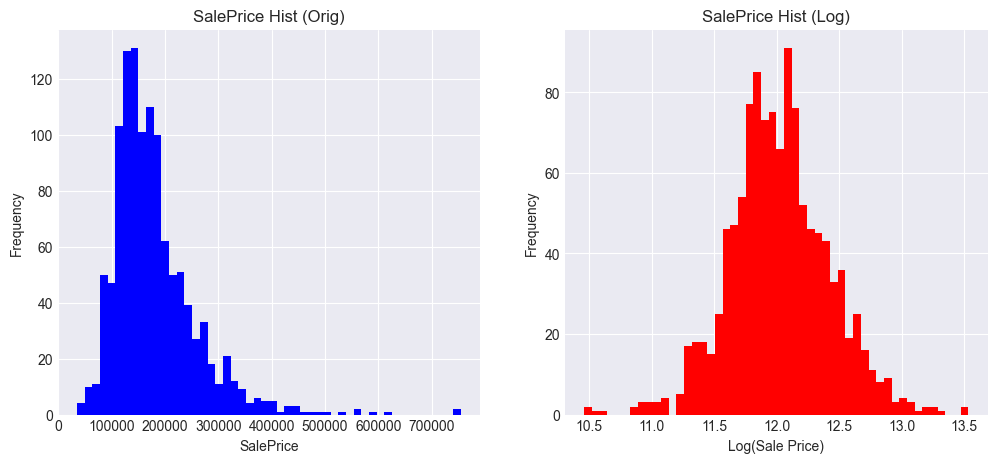

In [336]:
# 주택 가격 분포 확인, 정규성검토 -> 로그 변환 후 분포가 정규분포에 더 가까움 

# SalePrice 분포 시각화
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 1. 히스토그램
axes[0].hist(train_df['SalePrice'], bins=50, color='blue')
axes[0].set_xlabel('SalePrice')
axes[0].set_ylabel('Frequency')
axes[0].set_title('SalePrice Hist (Orig)')


# 3. 로그 변환 후 히스토그램
log_saleprice = np.log1p(train_df['SalePrice'])  # log1p = log(1 + x) -> 0값 처리
axes[1].hist(log_saleprice, bins=50, color='red')
axes[1].set_xlabel('Log(Sale Price)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('SalePrice Hist (Log)')


plt.show()

## 3.2 결측치 분석

In [337]:
# 결측치 확인
missing_train = train_df.isnull().sum()
missing_train.sort_values(ascending=False)

PoolQC           1162
MiscFeature      1120
Alley            1098
Fence             941
MasVnrType        694
FireplaceQu       545
LotFrontage       218
GarageYrBlt        69
GarageCond         69
GarageType         69
GarageFinish       69
GarageQual         69
BsmtFinType2       24
BsmtExposure       24
BsmtQual           23
BsmtCond           23
BsmtFinType1       23
MasVnrArea          8
Electrical          1
Id                  0
Functional          0
Fireplaces          0
KitchenQual         0
KitchenAbvGr        0
BedroomAbvGr        0
HalfBath            0
FullBath            0
BsmtHalfBath        0
TotRmsAbvGrd        0
GarageCars          0
GrLivArea           0
GarageArea          0
PavedDrive          0
WoodDeckSF          0
OpenPorchSF         0
EnclosedPorch       0
3SsnPorch           0
ScreenPorch         0
PoolArea            0
MiscVal             0
MoSold              0
YrSold              0
SaleType            0
SaleCondition       0
BsmtFullBath        0
HeatingQC 

In [338]:
# 결측치 비율
missing_train_per = train_df.isnull().mean()
missing_train_per.sort_values(ascending=False)


PoolQC          0.9949
MiscFeature     0.9589
Alley           0.9401
Fence           0.8057
MasVnrType      0.5942
FireplaceQu     0.4666
LotFrontage     0.1866
GarageYrBlt     0.0591
GarageCond      0.0591
GarageType      0.0591
GarageFinish    0.0591
GarageQual      0.0591
BsmtFinType2    0.0205
BsmtExposure    0.0205
BsmtQual        0.0197
BsmtCond        0.0197
BsmtFinType1    0.0197
MasVnrArea      0.0068
Electrical      0.0009
Id              0.0000
Functional      0.0000
Fireplaces      0.0000
KitchenQual     0.0000
KitchenAbvGr    0.0000
BedroomAbvGr    0.0000
HalfBath        0.0000
FullBath        0.0000
BsmtHalfBath    0.0000
TotRmsAbvGrd    0.0000
GarageCars      0.0000
GrLivArea       0.0000
GarageArea      0.0000
PavedDrive      0.0000
WoodDeckSF      0.0000
OpenPorchSF     0.0000
EnclosedPorch   0.0000
3SsnPorch       0.0000
ScreenPorch     0.0000
PoolArea        0.0000
MiscVal         0.0000
MoSold          0.0000
YrSold          0.0000
SaleType        0.0000
SaleConditi

## 3.3 상관관계 분석

### 수치형, 변수간 상관관계 + VIF

In [339]:
# 수치형 변수 선택
numeric_cols = train_df.select_dtypes(include=[np.number]).columns
correlation_matrix = train_df[numeric_cols].corr()


# 상관계수 절댓값 기준으로 높은 순 정렬
def get_high_corr_pairs(corr_matrix, threshold=0.7):
    """threshold 이상의 상관관계를 가진 변수 쌍 추출"""
    high_corr = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            if abs(corr_matrix.iloc[i, j]) >= threshold:
                high_corr.append({
                    'var1': corr_matrix.columns[i],
                    'var2': corr_matrix.columns[j],
                    'correlation': corr_matrix.iloc[i, j]
                })
    return pd.DataFrame(high_corr).sort_values('correlation',
                                               key=abs,
                                               ascending=False)


high_corr_pairs = get_high_corr_pairs(correlation_matrix, threshold=0.7)
print(high_corr_pairs)




          var1          var2  correlation
5   GarageCars    GarageArea       0.8823
2  TotalBsmtSF      1stFlrSF       0.8374
3    GrLivArea  TotRmsAbvGrd       0.8290
1    YearBuilt   GarageYrBlt       0.8281
0  OverallQual     SalePrice       0.7851
4    GrLivArea     SalePrice       0.7102


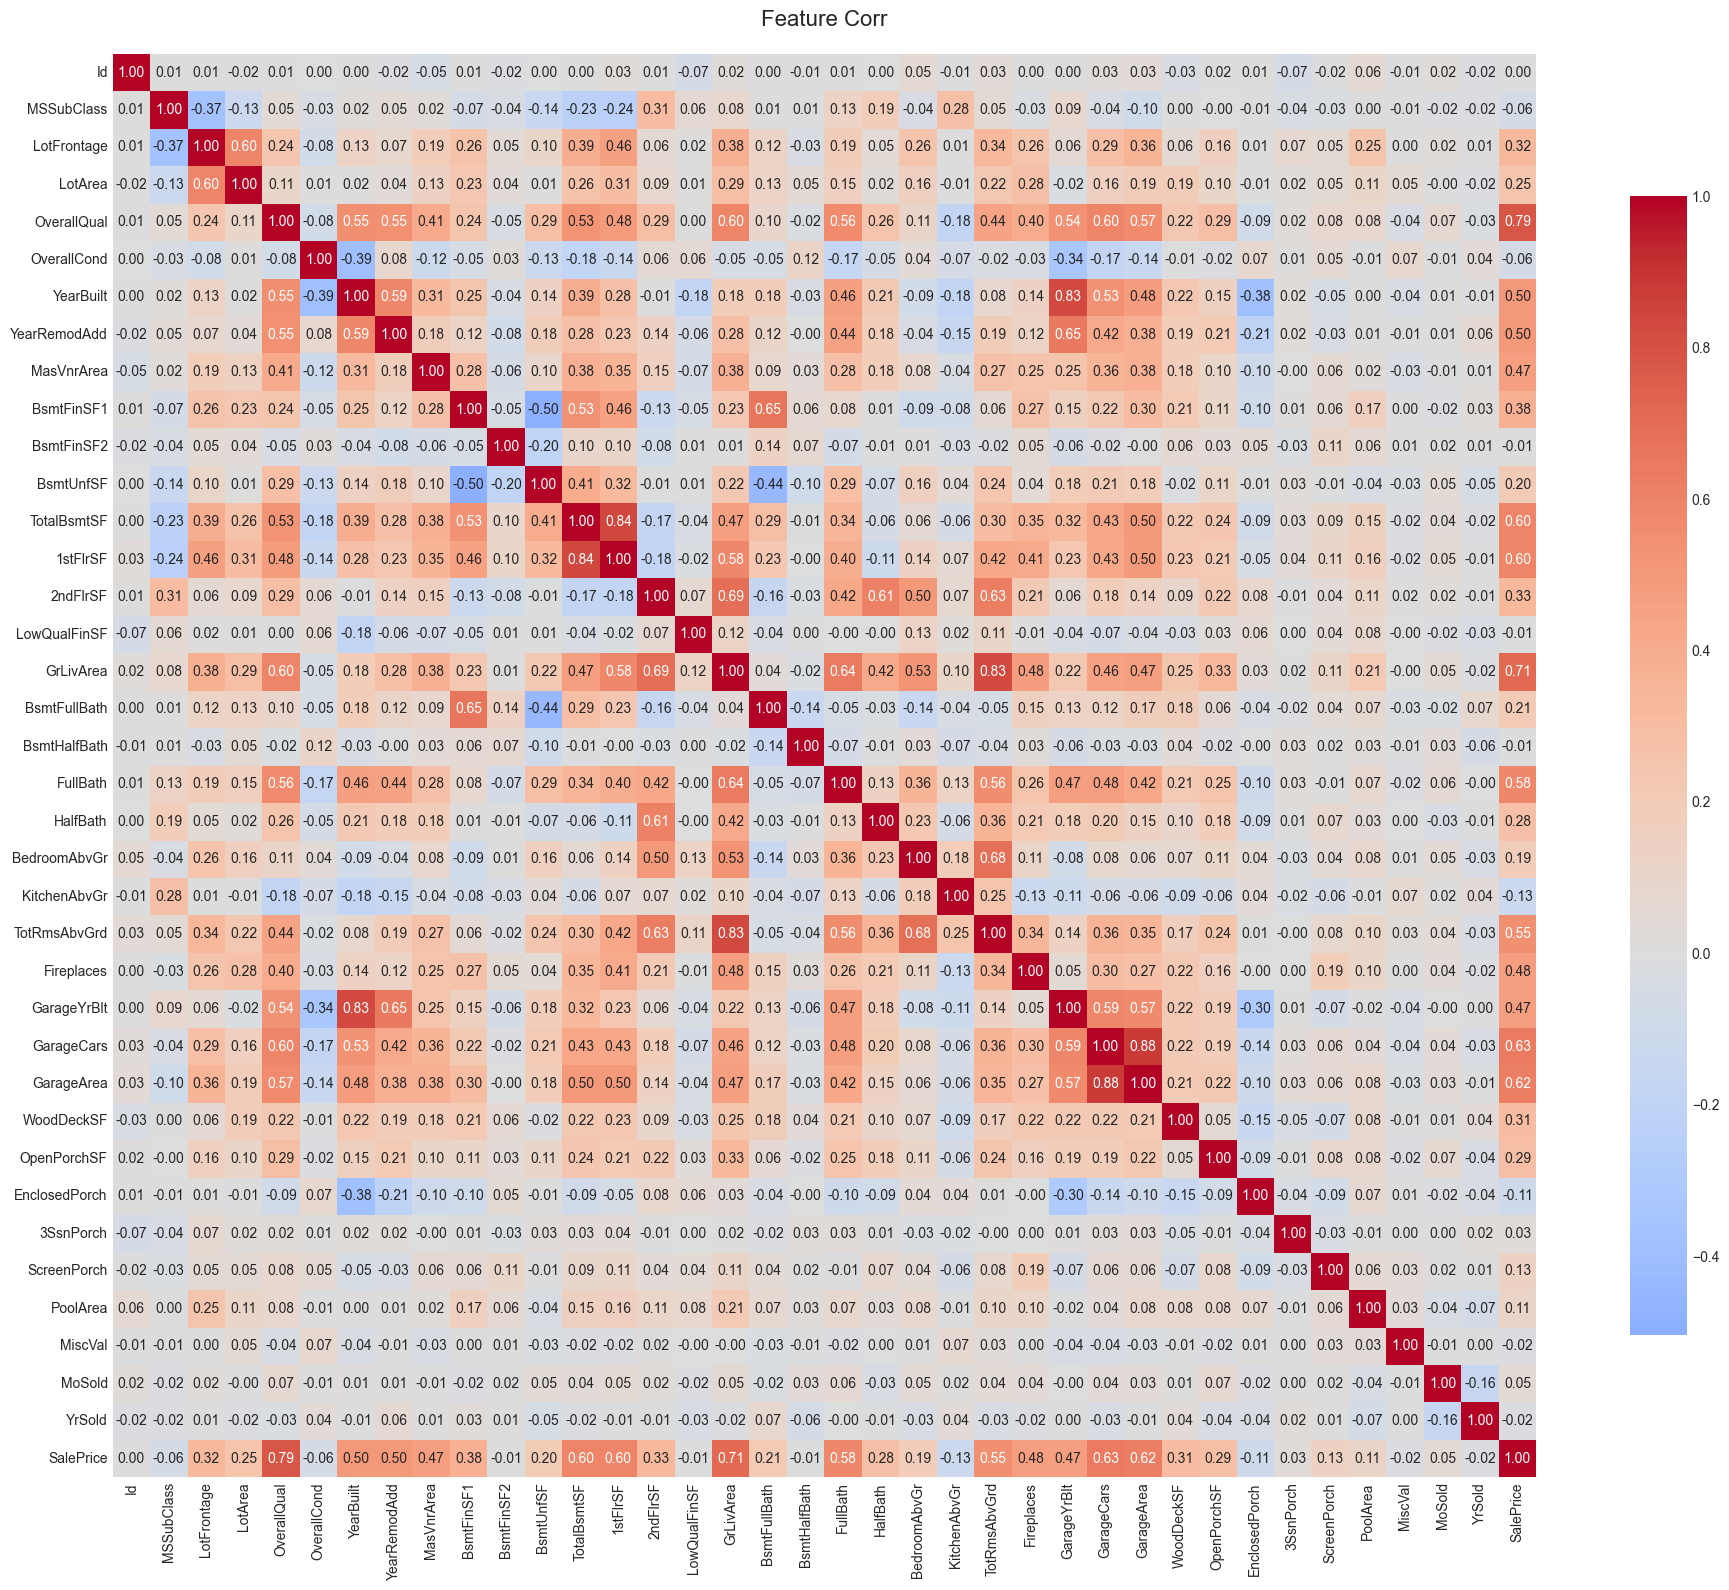

In [340]:
# 히트맵 시각화
plt.figure(figsize=(20, 16))
sns.heatmap(correlation_matrix,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',  # 색상: 빨강(양), 파랑(음)
            center=0,    # 0을 중심으로 색상 분포
            square=True,
            cbar_kws={"shrink": 0.8})
plt.title('Feature Corr', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

In [341]:
# VIF 계산
# 수치형 변수만 선택 (target 변수 제외)
# Id는 식별자이므로 제외
feature_cols = numeric_cols.drop(['Id', 'SalePrice'])  # SalePrice가 target이라 가정
X = train_df[feature_cols]


# 결측치 처리 (VIF 계산 전 필수)
X = X.fillna(X.median())


# VIF 계산
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i)
                   for i in range(len(X.columns))]

# VIF 높은 순 정렬
vif_data = vif_data.sort_values('VIF', ascending=False)
vif_data

# 문제 변수 필터링
print(vif_data[vif_data['VIF'] > 10])
print(vif_data[vif_data['VIF'] > 5])

         Feature        VIF
9     BsmtFinSF2        inf
8     BsmtFinSF1        inf
15     GrLivArea        inf
14  LowQualFinSF        inf
13      2ndFlrSF        inf
12      1stFlrSF        inf
11   TotalBsmtSF        inf
10     BsmtUnfSF        inf
35        YrSold 23387.2520
6   YearRemodAdd 23030.1563
24   GarageYrBlt 22148.8279
5      YearBuilt 20828.7512
22  TotRmsAbvGrd    84.0040
3    OverallQual    65.8456
4    OverallCond    41.5631
21  KitchenAbvGr    36.3936
25    GarageCars    36.3384
26    GarageArea    32.8338
20  BedroomAbvGr    30.9513
18      FullBath    26.7229
1    LotFrontage    16.8778
         Feature        VIF
9     BsmtFinSF2        inf
8     BsmtFinSF1        inf
15     GrLivArea        inf
14  LowQualFinSF        inf
13      2ndFlrSF        inf
12      1stFlrSF        inf
11   TotalBsmtSF        inf
10     BsmtUnfSF        inf
35        YrSold 23387.2520
6   YearRemodAdd 23030.1563
24   GarageYrBlt 22148.8279
5      YearBuilt 20828.7512
22  TotRmsAbvGrd    

### 수치형

In [342]:
# 수치형 변수만 선택
numeric_features = train_df.select_dtypes(include=[np.number]).columns.tolist()

# SalePrice와 상관계수 계산
correlations = train_df[numeric_features].corr()['SalePrice'].sort_values(ascending=False)
correlations

SalePrice        1.0000
OverallQual      0.7851
GrLivArea        0.7102
GarageCars       0.6326
GarageArea       0.6183
1stFlrSF         0.5977
TotalBsmtSF      0.5959
FullBath         0.5779
TotRmsAbvGrd     0.5488
YearRemodAdd     0.5048
YearBuilt        0.5018
Fireplaces       0.4760
GarageYrBlt      0.4725
MasVnrArea       0.4693
BsmtFinSF1       0.3796
2ndFlrSF         0.3332
LotFrontage      0.3214
WoodDeckSF       0.3081
OpenPorchSF      0.2948
HalfBath         0.2793
LotArea          0.2516
BsmtFullBath     0.2097
BsmtUnfSF        0.1973
BedroomAbvGr     0.1862
ScreenPorch      0.1331
PoolArea         0.1144
MoSold           0.0493
3SsnPorch        0.0287
Id               0.0032
BsmtFinSF2      -0.0051
BsmtHalfBath    -0.0055
LowQualFinSF    -0.0079
YrSold          -0.0182
MiscVal         -0.0218
OverallCond     -0.0599
MSSubClass      -0.0607
EnclosedPorch   -0.1103
KitchenAbvGr    -0.1329
Name: SalePrice, dtype: float64

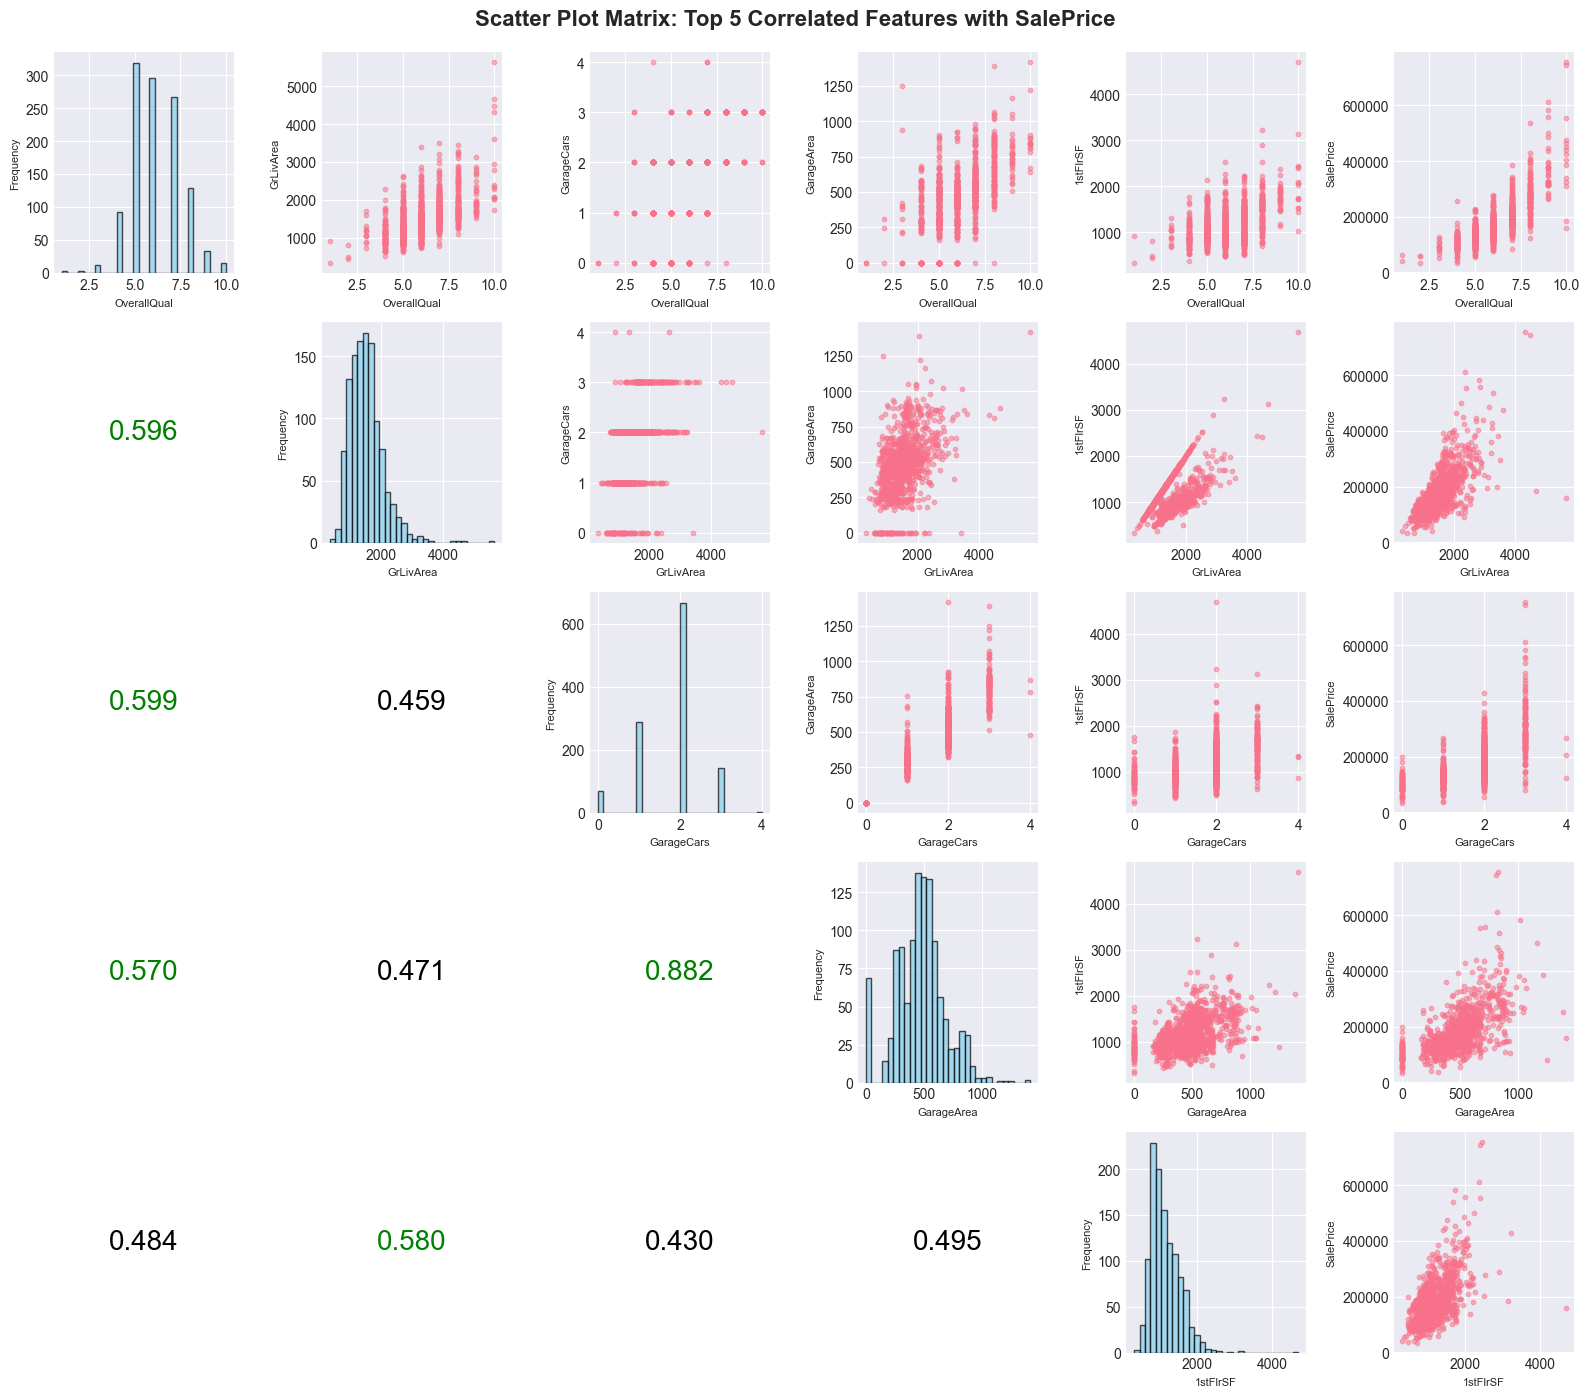

In [343]:
# 상위 상관관계 변수들 scatterplot
top_features = correlations.head(6)[1:].index.tolist()  # 상위 5개 변수
top_features.append('SalePrice')

fig = plt.figure(figsize=(16, 14))
for i, feature in enumerate(top_features[:-1]):
    for j, feature2 in enumerate(top_features):
        ax = plt.subplot(5, 6, i * 6 + j + 1)
        if i < j:
            # 상단 삼각형: 산점도
            ax.scatter(train_df[feature], train_df[feature2], alpha=0.5, s=10)
            ax.set_xlabel(feature, fontsize=8)
            ax.set_ylabel(feature2, fontsize=8)
        elif i == j:
            # 대각선: 히스토그램
            ax.hist(train_df[feature], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
            ax.set_ylabel('Frequency', fontsize=8)
            ax.set_xlabel(feature, fontsize=8)
        else:
            # 하단 삼각형: 상관계수
            corr_val = train_df[[feature, feature2]].corr().iloc[0, 1]
            ax.text(0.5, 0.5, f'{corr_val:.3f}', 
                   ha='center', va='center', fontsize=20, 
                   color='green' if abs(corr_val) > 0.5 else 'black')
            ax.set_xlim([0, 1])
            ax.set_ylim([0, 1])
            ax.axis('off')

plt.suptitle('Scatter Plot Matrix: Top 5 Correlated Features with SalePrice', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

In [344]:
# 수치형 변수 선택
numeric_cols = train_df.select_dtypes(include=[np.number]).columns
correlation_matrix = train_df[numeric_cols].corr()

# 상관계수 절댓값 기준으로 높은 순 정렬
def get_high_corr_pairs(corr_matrix, threshold=0.7):
    """threshold 이상의 상관관계를 가진 변수 쌍 추출"""
    high_corr = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            if abs(corr_matrix.iloc[i, j]) >= threshold:
                high_corr.append({
                    'var1': corr_matrix.columns[i],
                    'var2': corr_matrix.columns[j],
                    'correlation': corr_matrix.iloc[i, j]
                })
    return pd.DataFrame(high_corr).sort_values('correlation', 
                                               key=abs, 
                                               ascending=False)

high_corr_pairs = get_high_corr_pairs(correlation_matrix, threshold=0.7)
print(high_corr_pairs)

          var1          var2  correlation
5   GarageCars    GarageArea       0.8823
2  TotalBsmtSF      1stFlrSF       0.8374
3    GrLivArea  TotRmsAbvGrd       0.8290
1    YearBuilt   GarageYrBlt       0.8281
0  OverallQual     SalePrice       0.7851
4    GrLivArea     SalePrice       0.7102


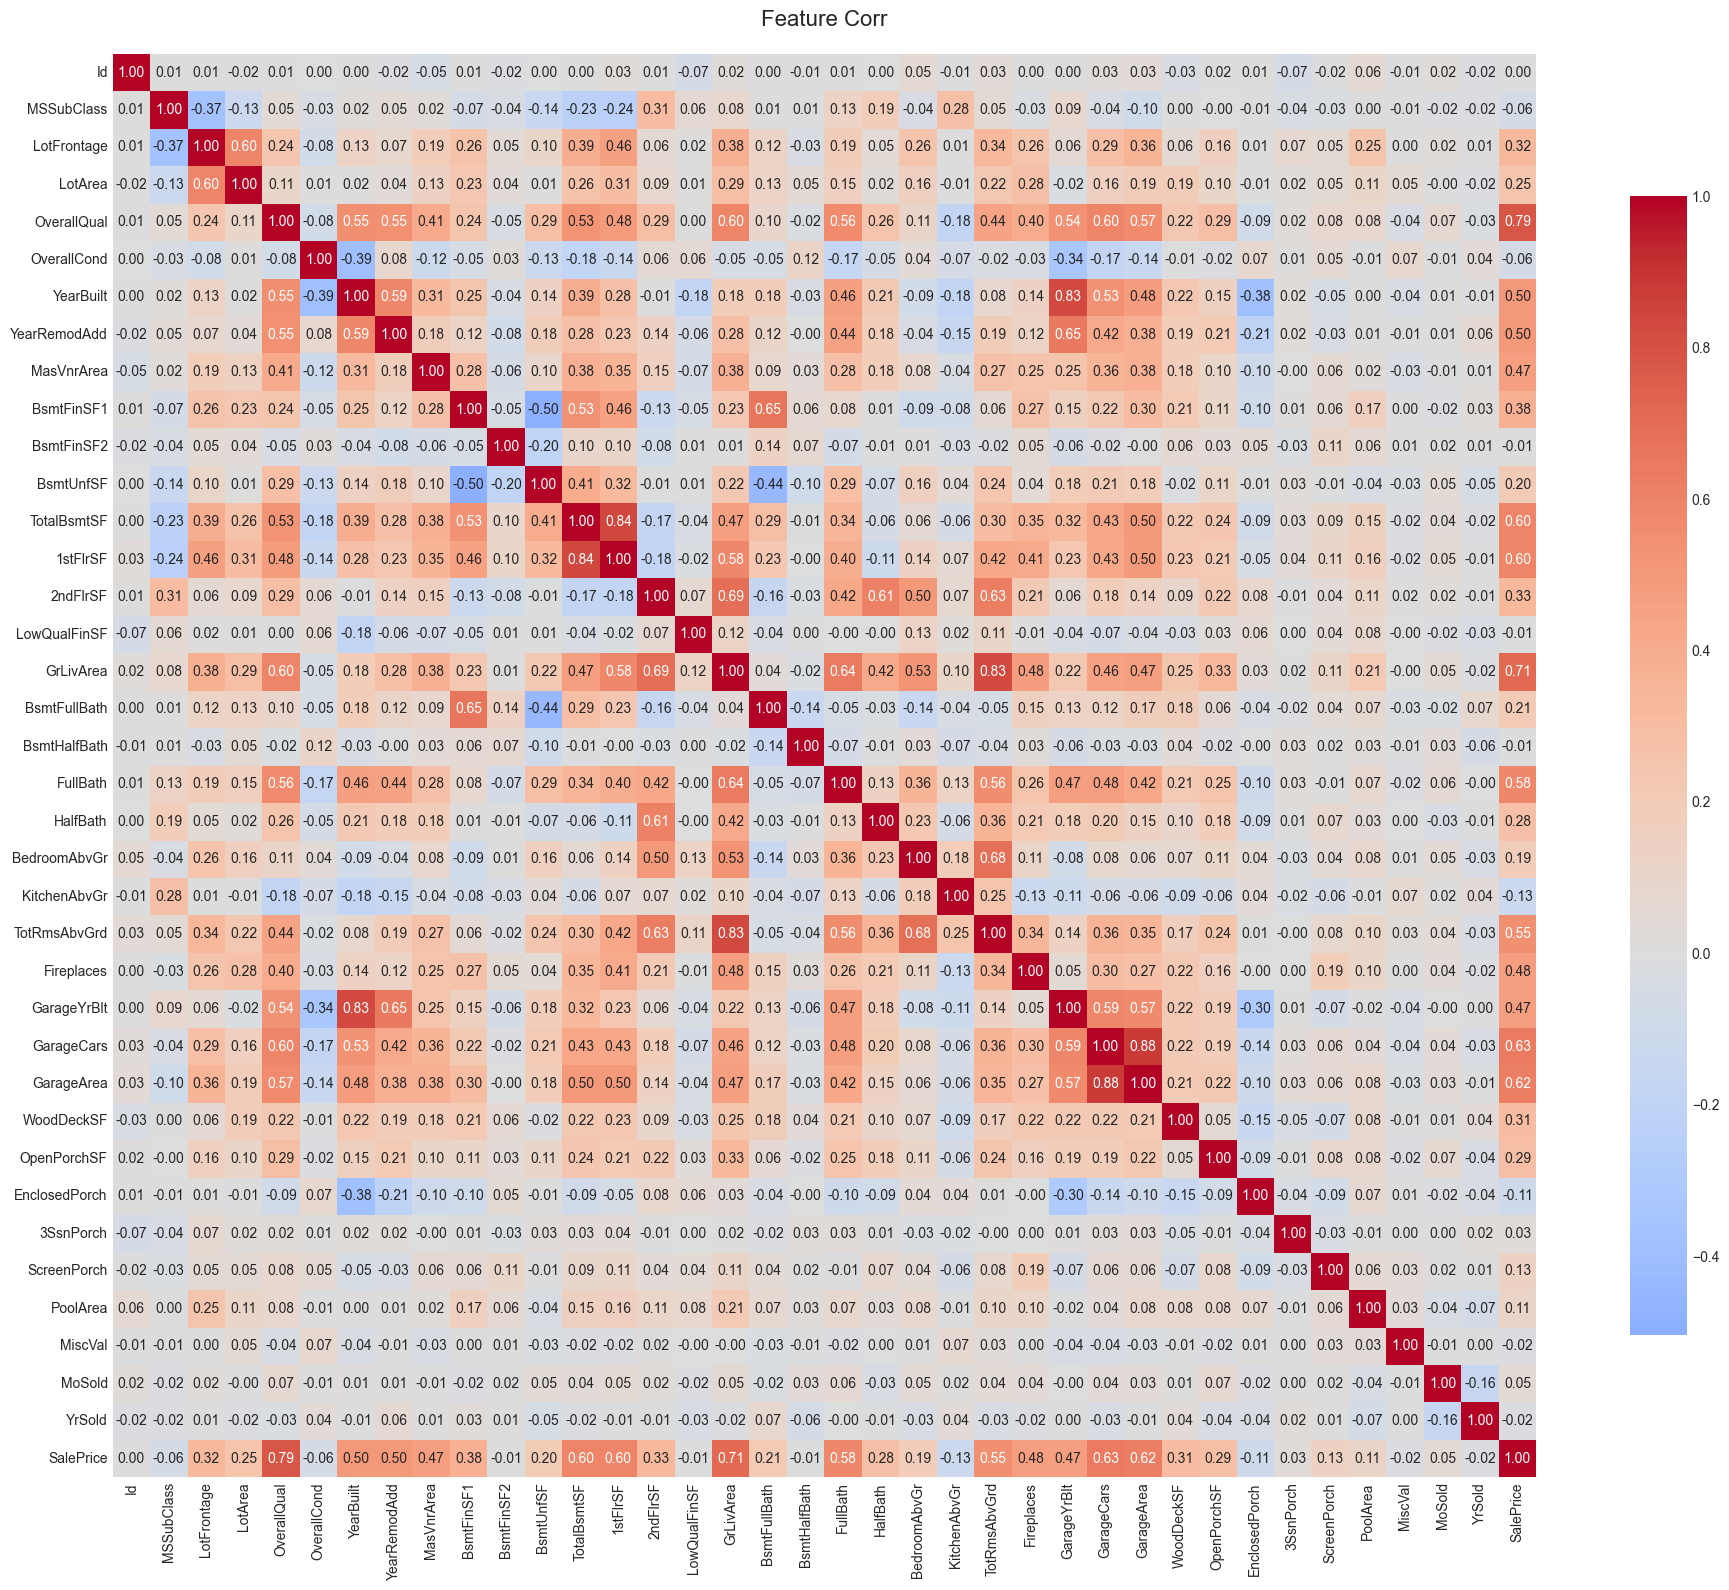

In [345]:
# 히트맵 시각화
plt.figure(figsize=(20, 16))
sns.heatmap(correlation_matrix, 
            annot=True, 
            fmt='.2f', 
            cmap='coolwarm',  # 색상: 빨강(양), 파랑(음)
            center=0,    # 0을 중심으로 색상 분포
            square=True,
            cbar_kws={"shrink": 0.8})
plt.title('Feature Corr', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

In [346]:
# VIF 계산
# 수치형 변수만 선택 (target 변수 제외)
# Id는 식별자이므로 제외
feature_cols = numeric_cols.drop(['Id', 'SalePrice'])  # SalePrice가 target이라 가정
X = train_df[feature_cols]

# 결측치 처리 (VIF 계산 전 필수)
X = X.fillna(X.median())

# VIF 계산
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) 
                   for i in range(len(X.columns))]

# VIF 높은 순 정렬
vif_data = vif_data.sort_values('VIF', ascending=False)
vif_data

# 문제 변수 필터링
print(vif_data[vif_data['VIF'] > 10])
print(vif_data[vif_data['VIF'] > 5])

         Feature        VIF
9     BsmtFinSF2        inf
8     BsmtFinSF1        inf
15     GrLivArea        inf
14  LowQualFinSF        inf
13      2ndFlrSF        inf
12      1stFlrSF        inf
11   TotalBsmtSF        inf
10     BsmtUnfSF        inf
35        YrSold 23387.2520
6   YearRemodAdd 23030.1563
24   GarageYrBlt 22148.8279
5      YearBuilt 20828.7512
22  TotRmsAbvGrd    84.0040
3    OverallQual    65.8456
4    OverallCond    41.5631
21  KitchenAbvGr    36.3936
25    GarageCars    36.3384
26    GarageArea    32.8338
20  BedroomAbvGr    30.9513
18      FullBath    26.7229
1    LotFrontage    16.8778
         Feature        VIF
9     BsmtFinSF2        inf
8     BsmtFinSF1        inf
15     GrLivArea        inf
14  LowQualFinSF        inf
13      2ndFlrSF        inf
12      1stFlrSF        inf
11   TotalBsmtSF        inf
10     BsmtUnfSF        inf
35        YrSold 23387.2520
6   YearRemodAdd 23030.1563
24   GarageYrBlt 22148.8279
5      YearBuilt 20828.7512
22  TotRmsAbvGrd    

### 범주형

In [347]:
# 범주형 변수 선택
categorical_features = train_df.select_dtypes(include=['object']).columns.tolist()
print(len(categorical_features))
categorical_features

43


['MSZoning',
 'Street',
 'Alley',
 'LotShape',
 'LandContour',
 'Utilities',
 'LotConfig',
 'LandSlope',
 'Neighborhood',
 'Condition1',
 'Condition2',
 'BldgType',
 'HouseStyle',
 'RoofStyle',
 'RoofMatl',
 'Exterior1st',
 'Exterior2nd',
 'MasVnrType',
 'ExterQual',
 'ExterCond',
 'Foundation',
 'BsmtQual',
 'BsmtCond',
 'BsmtExposure',
 'BsmtFinType1',
 'BsmtFinType2',
 'Heating',
 'HeatingQC',
 'CentralAir',
 'Electrical',
 'KitchenQual',
 'Functional',
 'FireplaceQu',
 'GarageType',
 'GarageFinish',
 'GarageQual',
 'GarageCond',
 'PavedDrive',
 'PoolQC',
 'Fence',
 'MiscFeature',
 'SaleType',
 'SaleCondition']

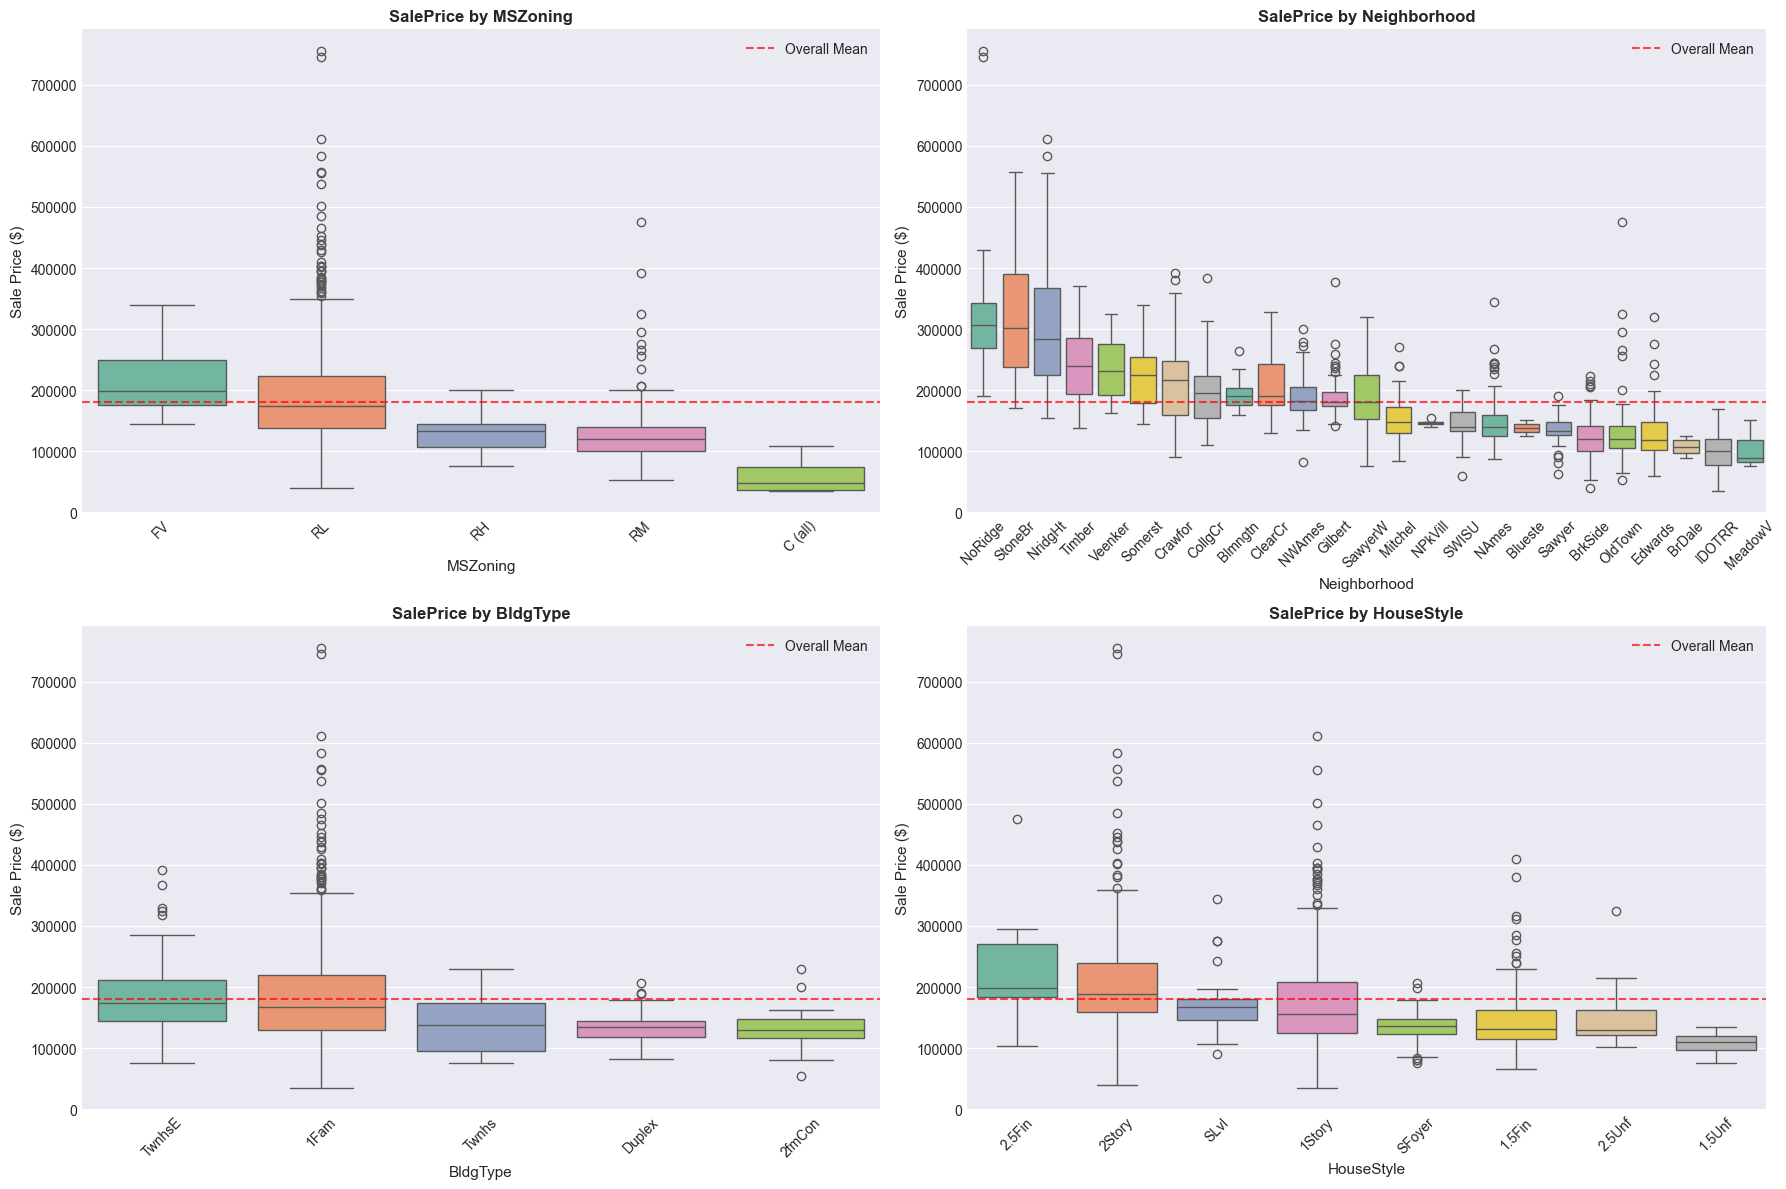

In [348]:
# 주요 범주형 변수-SalePrice 시각화

# 카테고리 수가 적은 변수들 선택
key_categorical = ['MSZoning', 'Neighborhood', 'BldgType', 'HouseStyle']

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

for i, cat in enumerate(key_categorical):
    if cat in train_df.columns:
        # 카테고리별 평균 가격 계산 및 정렬
        cat_order = train_df.groupby(cat)['SalePrice'].median().sort_values(ascending=False).index
        
        sns.boxplot(data=train_df, x=cat, y='SalePrice', order=cat_order, ax=axes[i], palette='Set2')
        axes[i].set_title(f'SalePrice by {cat}', fontsize=12, fontweight='bold')
        axes[i].set_xlabel(cat, fontsize=11)
        axes[i].set_ylabel('Sale Price ($)', fontsize=11)
        axes[i].tick_params(axis='x', rotation=45)
        
        # 평균선 추가
        axes[i].axhline(train_df['SalePrice'].mean(), color='red', linestyle='--', 
                       linewidth=1.5, alpha=0.7, label='Overall Mean')
        axes[i].legend()

plt.tight_layout()
plt.show()

# 4. 데이터 전처리


## 4.0 전처리 파이프라인 

In [349]:
"""
사용 예시

# 실행
datasets, metadata = run_preprocessing_pipeline(train_df, test_df)

# 검증용 모델 학습
model.fit(datasets['X_train_scaled'], datasets['y_train_split'])
val_score = model.score(datasets['X_val_scaled'], datasets['y_val_split'])

# 최종 제출용 모델 재학습
final_model.fit(datasets['X_train_full_scaled'], datasets['y_train_full'])
predictions = final_model.predict(datasets['X_submission_scaled'])

# 제출 파일 생성
submission = pd.DataFrame({
    'Id': metadata['test_ids'],
    'SalePrice': np.expm1(predictions)  # 로그 역변환
})
"""

"\n사용 예시\n\n# 실행\ndatasets, metadata = run_preprocessing_pipeline(train_df, test_df)\n\n# 검증용 모델 학습\nmodel.fit(datasets['X_train_scaled'], datasets['y_train_split'])\nval_score = model.score(datasets['X_val_scaled'], datasets['y_val_split'])\n\n# 최종 제출용 모델 재학습\nfinal_model.fit(datasets['X_train_full_scaled'], datasets['y_train_full'])\npredictions = final_model.predict(datasets['X_submission_scaled'])\n\n# 제출 파일 생성\nsubmission = pd.DataFrame({\n    'Id': metadata['test_ids'],\n    'SalePrice': np.expm1(predictions)  # 로그 역변환\n})\n"

## 4.1 전처리 데이터셋 만들기

In [350]:
# train과 test 데이터를 합쳐서 전처리 (일관성 유지)
"""
● 안전한 전처리 (합쳐도 되는 경우)
     - 행 단위 변환: 결측치 제거, 데이터 타입 변환, 문자열 정제
     - 범주형 인코딩: 라벨 인코딩, 원-핫 인코딩 (고정된 카테고리)
     - 일관성 작업: test에 없는 컬럼 제거, 동일한 결측치 처리 전략 적용
     이 경우 concat은 코드 중복 방지와 일관성 보장 측면에서 유효함 

● 위험한 전처리 (절대 합치면 안 되는 경우)
    - 통계량 기반 스케일링: StandardScaler, MinMaxScaler (test의 분포 정보 누수)
    - 피처 선택: SelectKBest, RFE (test 정보로 피처 중요도 왜곡)
    - 타겟 기반 인코딩: target encoding, mean encoding
    - 결측치 통계 대체: test의 평균/중앙값으로 train 영향
    이 경우 concat은 data leakage를 발생
"""
def create_prepro_dataset(train_df, test_df):
    """
    train과 test를 병합하여 전처리용 데이터셋 생성
    
    Returns:
        tuple: (all_data, metadata_dict)
        - all_data: 병합된 데이터프레임
        - metadata: {'train_len', 'test_ids', 'y_train'}
    """
    # 메타데이터 저장
    train_len = len(train_df)
    test_ids = test_df['Id'].copy()
    y_train = np.log1p(train_df['SalePrice'])
    
    # ID, Target 제거 후 병합
    X_train = train_df.drop(['Id', 'SalePrice'], axis=1)
    X_test = test_df.drop(['Id'], axis=1)
    all_data = pd.concat([X_train, X_test], axis=0, ignore_index=True)
    
    # 검증
    assert 'SalePrice' not in all_data.columns, "Target 확인 필요"
    assert 'Id' not in all_data.columns, "ID 컬럼 확인 필요"
    print(f"Train={train_len}, Test={len(test_ids)}, Total={len(all_data)}")
    
    metadata = {
        'train_len': train_len,
        'test_ids': test_ids,
        'y_train': y_train
    }
    
    return all_data, metadata


all_data, metadata = create_prepro_dataset(train_df, test_df) 

Train=1168, Test=292, Total=1460


## 4.2 결측치 처리

In [351]:
def handle_missing_values(df):
    """
    결측치 처리
        - 범주형 '없음': 'None' 대체
        - 수치형 '없음': 0 대체  
        - LotFrontage: Neighborhood별 중앙값
        - 나머지: 중앙값/최빈값
    """
    df = df.copy()
    
    # 1. '없음'을 의미하는 범주형
    none_cols = [
        'PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
        'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
        'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
        'MasVnrType'
    ]
    for col in none_cols:
        if col in df.columns:
            df[col] = df[col].fillna('None')
    
    # 2. '0'을 의미하는 수치형
    zero_cols = [
        'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF',
        'BsmtFullBath', 'BsmtHalfBath', 'GarageYrBlt', 'GarageCars', 'GarageArea'
    ]
    for col in zero_cols:
        if col in df.columns:
            df[col] = df[col].fillna(0)
    
    # 3. LotFrontage: 이웃별 중앙값
    if 'LotFrontage' in df.columns and 'Neighborhood' in df.columns:
        df['LotFrontage'] = df.groupby('Neighborhood')['LotFrontage'].transform(
            lambda x: x.fillna(x.median())
        )
    
    # 4. 나머지 수치형: 중앙값
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    for col in numeric_cols:
        if df[col].isnull().sum() > 0:
            df[col] = df[col].fillna(df[col].median())
    
    # 5. 나머지 범주형: 최빈값
    categorical_cols = df.select_dtypes(include=['object']).columns
    for col in categorical_cols:
        if df[col].isnull().sum() > 0:
            df[col] = df[col].fillna(df[col].mode()[0])
    
    remaining_nulls = df.isnull().sum().sum()
    print(f"남은 결측치 {remaining_nulls}")
    
    return df

all_data = handle_missing_values(all_data)

남은 결측치 0


## 4.3 파생 변수 생성

In [352]:
def create_derived_features(df):
    """
    도메인 지식 기반 파생 변수 생성
    """
    df = df.copy()
    
    # 면적 관련
    df['TotalSF'] = df['TotalBsmtSF'] + df['1stFlrSF'] + df['2ndFlrSF']
    df['TotalPorchSF'] = (df['OpenPorchSF'] + df['EnclosedPorch'] + 
                          df['3SsnPorch'] + df['ScreenPorch'])
    
    # 욕실 개수
    df['TotalBath'] = (df['FullBath'] + df['HalfBath'] * 0.5 + 
                       df['BsmtFullBath'] + df['BsmtHalfBath'] * 0.5)
    
    # 시간 변수
    df['HouseAge'] = df['YrSold'] - df['YearBuilt']
    df['RemodAge'] = df['YrSold'] - df['YearRemodAdd']
    df['IsRemodeled'] = (df['YearBuilt'] != df['YearRemodAdd']).astype(int)
    
    # 시설 유무
    df['HasGarage'] = (df['GarageArea'] > 0).astype(int)
    df['HasBsmt'] = (df['TotalBsmtSF'] > 0).astype(int)
    df['Has2ndFloor'] = (df['2ndFlrSF'] > 0).astype(int)
    df['HasPool'] = (df['PoolArea'] > 0).astype(int)
    
    new_features = ['TotalSF', 'TotalBath', 'TotalPorchSF', 'HouseAge', 
                    'RemodAge', 'IsRemodeled', 'HasGarage', 'HasBsmt', 
                    'Has2ndFloor', 'HasPool']
    return df

all_data = create_derived_features(all_data)

## 4.4 수치형 변수 왜도 처리

In [353]:

def handle_skewness(df, skew_threshold=0.75):
    """
    왜도가 높은 변수에 Box-Cox 변환 적용
    
    Returns:
        tuple: (transformed_df, transformation_log)
    """

    # 튜플 언패킹 
    if isinstance(df, tuple):
        df = df[0]
    
    df = df.copy()
    numeric_feats = df.select_dtypes(include=[np.number]).columns
    skewed_feats = [
        feat for feat in numeric_feats 
        if abs(df[feat].skew()) > skew_threshold
    ]
    
    transformation_log = {}


    
    for feat in skewed_feats:
        try:
            # 상수 변수 체크
            if df[feat].std() < 1e-10:
                transformation_log[feat] = "스킵: 상수"
                continue
            
            # Box-Cox 시도
            with warnings.catch_warnings():
                warnings.simplefilter("error")
                lambda_opt = boxcox_normmax(df[feat] + 1)
                df[feat] = boxcox1p(df[feat], lambda_opt)
                transformation_log[feat] = f"Box-Cox (λ={lambda_opt:.3f})"
                
        except Exception:
            # 실패 시 대체 전략
            if df[feat].min() >= 0:
                df[feat] = np.log1p(df[feat])
                transformation_log[feat] = "Log1p"
            else:
                from sklearn.preprocessing import PowerTransformer
                pt = PowerTransformer(method='yeo-johnson')
                df[[feat]] = pt.fit_transform(df[[feat]])
                transformation_log[feat] = "Yeo-Johnson"
    
    print(f"변환 변수: {len(transformation_log)}개")
    
    return df, transformation_log

all_data, transformation_log = handle_skewness(all_data, skew_threshold=0.75)
all_data

변환 변수: 27개


,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,TotalSF,TotalPorchSF,TotalBath,HouseAge,RemodAge,IsRemodeled,HasGarage,HasBsmt,Has2ndFloor,HasPool
0,4.1467,RL,11.0724,8.9080,Pave,None,IR1,Lvl,AllPub,Inside,Gtl,NAmes,Norm,Norm,1Fam,1Story,5,7,1955,1955,Hip,CompShg,Wd Sdng,Wd Sdng,BrkFace,17.1104,TA,TA,CBlock,TA,TA,No,ALQ,139.3204,Unf,0.0000,35.6981,307.0489,GasA,TA,Y,SBrkr,7.0022,0.0000,0.0000,7.2671,1,0.0000,1,0,3,0.7174,TA,6,Typ,0,None,Attchd,49261393995774963855732757782186807328701842791...,Unf,1,260,TA,TA,Y,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,None,None,None,0.0000,7,2008,WD,Normal,18.8616,0.0000,2.0000,53,53,0,7824.8387,0.6931,0,0.0000
1,7.2026,RL,10.0894,9.2874,Pave,None,Reg,Lvl,AllPub,Inside,Gtl,Edwards,Norm,Norm,Duplex,1Story,5,5,1987,1988,Gable,CompShg,Plywood,Plywood,None,0.0000,TA,TA,CBlock,Gd,Gd,Gd,GLQ,168.8523,Unf,0.0000,0.0000,329.2575,GasA,TA,Y,SBrkr,7.0909,0.0000,0.0000,7.3627,3,0.0000,3,0,3,0.7174,TA,5,Typ,0,None,None,0.0000,None,0,0,None,None,Y,33.7689,0.0000,0.0000,0.0000,0.0000,0.0000,None,None,None,0.0000,3,2009,WD,Alloca,19.2998,0.0000,6.0000,22,21,1,0.0000,0.6931,0,0.0000
2,4.1467,RL,9.5919,9.5333,Pave,None,IR1,Lvl,AllPub,Inside,Gtl,Timber,Norm,Norm,1Fam,1Story,6,6,1987,1987,Gable,CompShg,HdBoard,HdBoard,BrkFace,11.9663,TA,TA,CBlock,Gd,Gd,No,GLQ,147.3284,LwQ,5.2760,22.4271,310.1228,GasA,Gd,Y,SBrkr,7.0370,0.0000,0.0000,7.3047,1,0.0000,2,0,2,0.7174,Gd,5,Typ,1,TA,Attchd,92723298591931317408583376798172636945959162437...,Unf,2,551,TA,TA,Y,34.7173,0.0000,0.0000,0.0000,0.0000,0.0000,None,None,None,0.0000,7,2006,WD,Normal,18.9784,0.0000,3.0000,19,19,0,7824.8387,0.6931,0,0.0000
3,4.1467,RL,12.3961,9.3952,Pave,None,Reg,Lvl,AllPub,Inside,Gtl,NridgHt,Norm,Norm,1Fam,1Story,8,5,2007,2007,Hip,CompShg,VinylSd,VinylSd,BrkFace,21.8125,Ex,TA,PConc,Ex,TA,No,Unf,0.0000,Unf,0.0000,129.6696,431.7098,GasA,Ex,Y,SBrkr,7.4354,0.0000,0.0000,7.7347,0,0.0000,2,0,3,0.7174,Gd,7,Typ,0,None,Attchd,13697108716134476041295220959766869243164281721...,Fin,3,818,TA,TA,Y,42.4008,23.5059,0.0000,0.0000,0.0000,0.0000,None,None,None,0.0000,12,2007,New,Partial,21.0792,24.8562,2.0000,0,0,0,7824.8387,0.6931,0,0.0000
4,5.8914,RL,10.0894,8.9953,Pave,None,Reg,Lvl,AllPub,Corner,Gtl,NAmes,Artery,Norm,1Fam,1.5Fin,5,7,1949,2006,Gable,CompShg,MetalSd,MetalSd,None,0.0000,TA,Gd,CBlock,TA,TA,Mn,Unf,0.0000,Unf,0.0000,74.9181,208.6665,GasA,Ex,Y,SBrkr,6.5117,345.7441,0.0000,7.0817,0,0.0000,1,0,3,0.7174,TA,6,Typ,1,Po,Detchd,12672908934948763506615322017068690074283958469...,Unf,2,576,TA,TA,Y,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,None,MnPrv,Shed,8.3863,7,2007,WD,Normal,17.3517,0.0000,1.0000,58,1,1,7824.8387,0.6931,1,0.0000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,5.4341,RL,11.5582,10.0688,Pave,None,Reg,Low,AllPub,Inside,Sev,ClearCr,Norm,Norm,1Fam,1Story,7,6,1979,1979,Shed,WdShake,Plywood,Plywood,None,0.0000,Gd,TA,PConc,Gd,TA,Gd,GLQ,174.3012,Unf,0.0000,19.5789

## 4.5 범주형 변수 인코딩

In [354]:
def encode_ordinal_features(df):

    """
    순서형 변수를 숫자로 매핑 (Label Encoding)
    """
    df = df.copy()
    
    # 품질 매핑
    quality_map = {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'None': 0, 'NA': 0}
    quality_cols = ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 
                    'HeatingQC', 'KitchenQual', 'FireplaceQu', 
                    'GarageQual', 'GarageCond', 'PoolQC']
    for col in quality_cols:
        if col in df.columns:
            df[col] = df[col].map(quality_map).fillna(0)
    
    # 지하실 노출도
    bsmt_exposure_map = {'Gd': 4, 'Av': 3, 'Mn': 2, 'No': 1, 'None': 0, 'NA': 0}
    if 'BsmtExposure' in df.columns:
        df['BsmtExposure'] = df['BsmtExposure'].map(bsmt_exposure_map).fillna(0)
    
    # 지하실 마감
    bsmt_fin_map = {'GLQ': 6, 'ALQ': 5, 'BLQ': 4, 'Rec': 3, 
                    'LwQ': 2, 'Unf': 1, 'None': 0, 'NA': 0}
    for col in ['BsmtFinType1', 'BsmtFinType2']:
        if col in df.columns:
            df[col] = df[col].map(bsmt_fin_map).fillna(0)
    
    # 차고 마감
    garage_finish_map = {'Fin': 3, 'RFn': 2, 'Unf': 1, 'None': 0, 'NA': 0}
    if 'GarageFinish' in df.columns:
        df['GarageFinish'] = df['GarageFinish'].map(garage_finish_map).fillna(0)
    
    # 울타리 품질
    fence_map = {'GdPrv': 4, 'MnPrv': 3, 'GdWo': 2, 'MnWw': 1, 'None': 0, 'NA': 0}
    if 'Fence' in df.columns:
        df['Fence'] = df['Fence'].map(fence_map).fillna(0)
    
    return df

all_data = encode_ordinal_features(all_data)
all_data


,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,TotalSF,TotalPorchSF,TotalBath,HouseAge,RemodAge,IsRemodeled,HasGarage,HasBsmt,Has2ndFloor,HasPool
0,4.1467,RL,11.0724,8.9080,Pave,None,IR1,Lvl,AllPub,Inside,Gtl,NAmes,Norm,Norm,1Fam,1Story,5,7,1955,1955,Hip,CompShg,Wd Sdng,Wd Sdng,BrkFace,17.1104,3,3,CBlock,3,3,1,5,139.3204,1,0.0000,35.6981,307.0489,GasA,3,Y,SBrkr,7.0022,0.0000,0.0000,7.2671,1,0.0000,1,0,3,0.7174,3,6,Typ,0,0,Attchd,49261393995774963855732757782186807328701842791...,1,1,260,3,3,Y,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0,0,None,0.0000,7,2008,WD,Normal,18.8616,0.0000,2.0000,53,53,0,7824.8387,0.6931,0,0.0000
1,7.2026,RL,10.0894,9.2874,Pave,None,Reg,Lvl,AllPub,Inside,Gtl,Edwards,Norm,Norm,Duplex,1Story,5,5,1987,1988,Gable,CompShg,Plywood,Plywood,None,0.0000,3,3,CBlock,4,4,4,6,168.8523,1,0.0000,0.0000,329.2575,GasA,3,Y,SBrkr,7.0909,0.0000,0.0000,7.3627,3,0.0000,3,0,3,0.7174,3,5,Typ,0,0,None,0.0000,0,0,0,0,0,Y,33.7689,0.0000,0.0000,0.0000,0.0000,0.0000,0,0,None,0.0000,3,2009,WD,Alloca,19.2998,0.0000,6.0000,22,21,1,0.0000,0.6931,0,0.0000
2,4.1467,RL,9.5919,9.5333,Pave,None,IR1,Lvl,AllPub,Inside,Gtl,Timber,Norm,Norm,1Fam,1Story,6,6,1987,1987,Gable,CompShg,HdBoard,HdBoard,BrkFace,11.9663,3,3,CBlock,4,4,1,6,147.3284,2,5.2760,22.4271,310.1228,GasA,4,Y,SBrkr,7.0370,0.0000,0.0000,7.3047,1,0.0000,2,0,2,0.7174,4,5,Typ,1,3,Attchd,92723298591931317408583376798172636945959162437...,1,2,551,3,3,Y,34.7173,0.0000,0.0000,0.0000,0.0000,0.0000,0,0,None,0.0000,7,2006,WD,Normal,18.9784,0.0000,3.0000,19,19,0,7824.8387,0.6931,0,0.0000
3,4.1467,RL,12.3961,9.3952,Pave,None,Reg,Lvl,AllPub,Inside,Gtl,NridgHt,Norm,Norm,1Fam,1Story,8,5,2007,2007,Hip,CompShg,VinylSd,VinylSd,BrkFace,21.8125,5,3,PConc,5,3,1,1,0.0000,1,0.0000,129.6696,431.7098,GasA,5,Y,SBrkr,7.4354,0.0000,0.0000,7.7347,0,0.0000,2,0,3,0.7174,4,7,Typ,0,0,Attchd,13697108716134476041295220959766869243164281721...,3,3,818,3,3,Y,42.4008,23.5059,0.0000,0.0000,0.0000,0.0000,0,0,None,0.0000,12,2007,New,Partial,21.0792,24.8562,2.0000,0,0,0,7824.8387,0.6931,0,0.0000
4,5.8914,RL,10.0894,8.9953,Pave,None,Reg,Lvl,AllPub,Corner,Gtl,NAmes,Artery,Norm,1Fam,1.5Fin,5,7,1949,2006,Gable,CompShg,MetalSd,MetalSd,None,0.0000,3,4,CBlock,3,3,2,1,0.0000,1,0.0000,74.9181,208.6665,GasA,5,Y,SBrkr,6.5117,345.7441,0.0000,7.0817,0,0.0000,1,0,3,0.7174,3,6,Typ,1,1,Detchd,12672908934948763506615322017068690074283958469...,1,2,576,3,3,Y,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0,3,Shed,8.3863,7,2007,WD,Normal,17.3517,0.0000,1.0000,58,1,1,7824.8387,0.6931,1,0.0000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,5.4341,RL,11.5582,10.0688,Pave,None,Reg,Low,AllPub,Inside,Sev,ClearCr,Norm,Norm,1Fam,1Story,7,6,1979,1979,Shed,WdShake,Plywood,Plywood,None,0.0000,4,3,PConc,4,3,4,6,174.3012,1,0.0000,19.5789,357.4029,GasA,3,Y,SBrkr,7.1952,258.6348,0.0000,7.6204,2,0.0000,0,1,0,0.7174,4,4,Typ,1,3,Attchd,79238287405560791318596592735839789

In [355]:
def encode_nominal_features(df, small_threshold=5, large_threshold=15):
    """
    - 고유값 ≤ 5: 원-핫 인코딩
    - 5 < 고유값 ≤ 15: 빈도 인코딩
    - 고유값 > 15: 제거 또는 타겟 인코딩
    """
    df = df.copy()
    cat_cols = df.select_dtypes(include=['object']).columns
    
    onehot_cols = []
    freq_cols = []
    drop_cols = []
    
    for col in cat_cols:
        n_unique = df[col].nunique()
        
        if n_unique <= small_threshold:
            onehot_cols.append(col)
        elif n_unique <= large_threshold:
            freq_cols.append(col)
        else:
            drop_cols.append(col)
            print(f"{col} 제거: {n_unique}개 카테고리 (너무 많음)")
    
    # 원-핫
    if onehot_cols:
        df = pd.get_dummies(df, columns=onehot_cols, drop_first=True)
        print(f"원-핫: {len(onehot_cols)}개")
    
    # 빈도
    for col in freq_cols:
        freq_map = X_train[col].value_counts(normalize=True).to_dict()
        df[col + '_freq'] = df[col].map(freq_map)
        df = df.drop(col, axis=1)
    if freq_cols:
        print(f"빈도: {len(freq_cols)}개")
    
    # 제거
    if drop_cols:
        df = df.drop(drop_cols, axis=1)
    
    print(f"최종: {df.shape[1]}개 컬럼")
    
    return df

all_data = encode_nominal_features(all_data, small_threshold=5, large_threshold=15)
all_data

Neighborhood 제거: 25개 카테고리 (너무 많음)
Exterior2nd 제거: 16개 카테고리 (너무 많음)
원-핫: 14개
빈도: 12개
최종: 111개 컬럼


,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,ExterQual,ExterCond,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,HeatingQC,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Fireplaces,FireplaceQu,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscVal,MoSold,YrSold,TotalSF,TotalPorchSF,TotalBath,HouseAge,RemodAge,IsRemodeled,HasGarage,HasBsmt,Has2ndFloor,HasPool,MSZoning_FV,MSZoning_RH,MSZoning_RL,MSZoning_RM,Street_Pave,Alley_None,Alley_Pave,LotShape_IR2,LotShape_IR3,LotShape_Reg,LandContour_HLS,LandContour_Low,LandContour_Lvl,Utilities_NoSeWa,LotConfig_CulDSac,LotConfig_FR2,LotConfig_FR3,LotConfig_Inside,LandSlope_Mod,LandSlope_Sev,BldgType_2fmCon,BldgType_Duplex,BldgType_Twnhs,BldgType_TwnhsE,MasVnrType_BrkFace,MasVnrType_None,MasVnrType_Stone,CentralAir_Y,Electrical_FuseF,Electrical_FuseP,Electrical_Mix,Electrical_SBrkr,PavedDrive_P,PavedDrive_Y,MiscFeature_None,MiscFeature_Othr,MiscFeature_Shed,MiscFeature_TenC,Condition1_freq,Condition2_freq,HouseStyle_freq,RoofStyle_freq,RoofMatl_freq,Exterior1st_freq,Foundation_freq,Heating_freq,Functional_freq,GarageType_freq,SaleType_freq,SaleCondition_freq
0,4.1467,11.0724,8.9080,5,7,1955,1955,17.1104,3,3,3,3,1,5,139.3204,1,0.0000,35.6981,307.0489,3,7.0022,0.0000,0.0000,7.2671,1,0.0000,1,0,3,0.7174,3,6,0,0,49261393995774963855732757782186807328701842791...,1,1,260,3,3,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0,0,0.0000,7,2008,18.8616,0.0000,2.0000,53,53,0,7824.8387,0.6931,0,0.0000,False,False,True,False,True,True,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,True,False,False,True,False,False,False,True,False,True,True,False,False,False,0.8630,0.9897,0.4973,0.1959,0.9822,0.1411,0.4342,0.9781,0.9315,0.5959,0.8678,0.8205
1,7.2026,10.0894,9.2874,5,5,1987,1988,0.0000,3,3,4,4,4,6,168.8523,1,0.0000,0.0000,329.2575,3,7.0909,0.0000,0.0000,7.3627,3,0.0000,3,0,3,0.7174,3,5,0,0,0.0000,0,0,0,0,0,33.7689,0.0000,0.0000,0.0000,0.0000,0.0000,0,0,0.0000,3,2009,19.2998,0.0000,6.0000,22,21,1,0.0000,0.6931,0,0.0000,False,False,True,False,True,True,False,False,False,True,False,False,True,False,False,False,False,True,False,False,False,True,False,False,False,True,False,True,False,False,False,True,False,True,True,False,False,False,0.8630,0.9897,0.4973,0.7815,0.9822,0.0740,0.4342,0.9781,0.9315,0.0555,0.8678,0.0082
2,4.1467,9.5919,9.5333,6,6,1987,1987,11.9663,3,3,4,4,1,6,147.3284,2,5.2760,22.4271,310.1228,4,7.0370,0.0000,0.0000,7.3047,1,0.0000,2,0,2,0.7174,4,5,1,3,92723298591931317408583376798172636945959162437...,1,2,551,3,3,34.7173,0.0000,0.0000,0.0000,0.0000,0.0000,0,0,0.0000,7,2006,18.9784,0.0000,3.0000,19,19,0,7824.8387,0.6931,0,0.0000,False,False,True,False,True,True,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,True,False,False,True,False,False,False,True,False,True,True,False,False,False,0.8630,0.9897,0.4973,0.7815,0.9822,0.1521,0.4342,0.9781,0.9315,0.5959,0.8678,0.8205
3,4.1467,12.3961,9.3952,8,5,2007,2007,21.8125,5,3,5,3,1,1,0.0000,1,0.0000,129.6696,431.7098,5,7.4354,0.0000,0.0000,7.7347,0,0.0000,2,0,3,0.7174,4,7,0,0,13697108716134476041295220959766869243164281721...,3,3,818,3,3,42.4008,23.5059,0.0000,0.0000,0.0000,0.0000,0,0,0.0000,12,2007,21.0792,24.8562,2.0000,0,0,0,7824.8387,0.6931,0,0.0000,False,False,True,False,True,True,False,False,False,True,False,False,True,False,False,False,False,True,False,False,False,False,False,False,True,False,False,True,False,False,False,True,False,True,True,False,False,False,0.8630,0.9897,0.4973,0.1959,0.9822,0.3527,0.4432,0.9781,0.9315,0.5959,0.0836,0.0856
4,5.8914,10.0894,8.9953,5,7,1949,2006,0.0000,3,4,3,3,2,1,0.0000,1,0.0000,74.9181,208.6665,5,6.5117,345.7441,0.00

## 4.6 데이터 재분리

In [356]:
def split_data(all_data, metadata):
    """
    전처리 완료된 데이터를 train/test로 재분리
    
    Returns:
        tuple: (X_train, X_submission, y_train)
    """
    train_len = metadata['train_len']
    y_train = metadata['y_train']
    
    X_train = all_data.iloc[:train_len].copy()
    X_submission = all_data.iloc[train_len:].copy()
    
    # 크기 검증
    assert len(X_train) == len(y_train), f"크기 불일치: X={len(X_train)}, y={len(y_train)}"
    print(f"Train={len(X_train)}, Submission={len(X_submission)}")
    
    return X_train, X_submission, y_train

X_train, X_submission, y_train = split_data(all_data, metadata)

Train=1168, Submission=292


In [357]:
X_train.describe()

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,ExterQual,ExterCond,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,HeatingQC,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Fireplaces,FireplaceQu,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscVal,MoSold,YrSold,TotalSF,TotalPorchSF,TotalBath,HouseAge,RemodAge,IsRemodeled,HasGarage,HasBsmt,Has2ndFloor,HasPool,Condition1_freq,Condition2_freq,HouseStyle_freq,RoofStyle_freq,RoofMatl_freq,Exterior1st_freq,Foundation_freq,Heating_freq,Functional_freq,GarageType_freq,SaleType_freq,SaleCondition_freq
count,1168.0000,1168.0000,1168.0000,1168.0000,1168.0000,1168.0000,1168.0000,1168.0000,1168.0000,1168.0000,1168.0000,1168.0000,1168.0000,1168.0000,1168.0000,1168.0000,1168.0000,1168.0000,1168.0000,1168.0000,1168.0000,1168.0000,1168.0000,1168.0000,1168.0000,1168.0000,1168.0000,1168.0000,1168.0000,1168.0000,1168.0000,1168.0000,1168.0000,1168.0000,1168.0000,1168.0000,1168.0000,1168.0000,1168.0000,1168.0000,1168.0000,1168.0000,1168.0000,1168.0000,1168.0000,1168.0000,1168.0000,1168.0000,1168.0000,1168.0000,1168.0000,1168.0000,1168.0000,1168.0000,1168.0000,1168.0000,1168.0000,1168.0000,1168.0000,1168.0000,1168.0000,1168.0000,1168.0000,1168.0000,1168.0000,1168.0000,1168.0000,1168.0000,1168.0000,1168.0000,1168.0000,1168.0000,1168.0000
mean,5.7519,10.7210,9.1043,6.1053,5.5959,1971.2012,1985.0214,8.1976,3.4067,3.0848,3.5000,2.9580,1.6250,3.5625,72.4862,1.2354,1.0952,62.1688,294.1217,4.1541,7.0066,514.4082,0.0671,7.5503,0.4255,0.0392,1.5625,0.3887,2.8656,0.7378,3.5231,6.5111,0.6259,1.8527,81825313554702289720906174592823353932497312372...,1.7003,1.7611,469.8887,2.7954,2.7945,21.1107,7.3953,2.0900,0.0870,1.6384,0.2799,0.0188,0.5702,0.2829,6.3065,2007.8305,19.4431,11.8143,2.2115,36.6293,22.8091,0.4743,7362.5837,0.6795,0.4264,0.0036,0.7472,0.9804,0.3543,0.6491,0.9655,0.1977,0.3942,0.9606,0.8712,0.4294,0.7641,0.6859
std,1.4784,1.5951,0.5091,1.3730,1.1274,30.3624,20.6933,10.9172,0.5794,0.3616,0.8331,0.5112,1.0521,2.1051,63.4257,0.8596,3.2166,33.1158,96.8063,0.9559,0.3201,661.8137,0.5380,0.3654,0.5183,0.1612,0.5519,0.5066,0.8248,0.0989,0.6722,1.6398,0.6542,1.8170,40904356346157540097494541342928501750758505590...,0.8980,0.7465,213.6048,0.7429,0.7363,25.4721,7.6898,5.2575,0.7014,5.5506,3.9110,0.2771,1.2049,1.4142,2.7160,1.3236,1.5657,10.0151,0.7911,30.4062,20.6552,0.4996,1845.6185,0.0963,0.4948,0.0496,0.2877,0.0954,0.1655,0.2514,0.1268,0.1196,0.1177,0.1289,0.2270,0.2108,0.2705,0.2888
min,4.1467,5.9589,7.1709,1.0000,1.0000,1872.0000,1950.0000,0.0000,2.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,5.8141,0.0000,0.0000,5.9960,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,2.0000,2.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,2006.0000,11.2373,0.0000,1.0000,0.0000,-1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0014,0.0007,0.0055,0.0014,0.0007,0.0007,0.0021,0.0014,0.0007,0.0041,0.0014,0.0027
25%,4.1467,10.0894,8.9308,5.0000,5.0000,1954.0000,1966.7500,0.0000,3.0000,3.0000,3.0000,3.0000,1.0000,1.0000,0.0000,1.0000,0.0000,39.6512,237.7098,3.0000,6.7811,0.0000,0.0000,7.2942,0.0000,0.0000,1.0000,0.0000,2.0000,0.7174,3.0000,5.0000,0.0000,0.0000,52293575679030842552884440198819792244148160872...,1.0000,1.0000,336.0000,3.0000,3.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,5.0000,2007.0000,18.4262,0.0000,2.0000,7.0000,4.0000,0.0000,7824.8387,0.6931,0.0000,0.0000,0.8630,0.9897,0.3048,0.7815,0.9822,0.1411,0.4342,0.9781,0.9315,0.2651,0.8678,0.8205
50%,5.8914,10.8556,9.1535,6.0000,5.0000,1972.5000,1994.0000,0.0000,3.0000,3.0000,4.0000,3.0000,1.0000,4.0000,76.8917,1.0000,0.0000,61.6959,283.0411,5.0000,6.98

In [358]:
y_train.describe()

count   1168.0000
mean      12.0206
std        0.3989
min       10.4603
25%       11.7714
50%       12.0076
75%       12.2693
max       13.5345
Name: SalePrice, dtype: float64

Text(0, 0.5, 'SalePrice (log)')

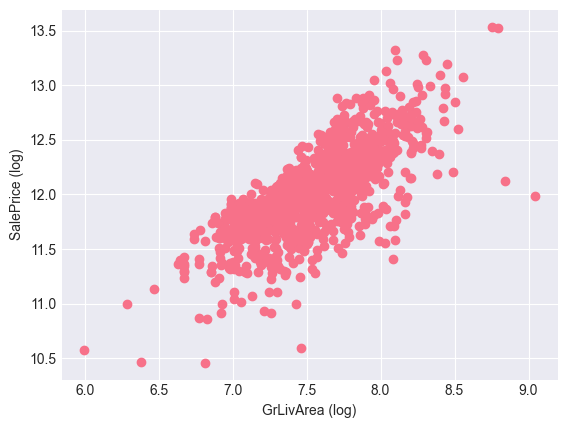

In [359]:
plt.scatter(X_train['GrLivArea'], y_train)
plt.xlabel('GrLivArea (log)')
plt.ylabel('SalePrice (log)')

## 4.7 이상치 처리

In [360]:
def remove_outliers_iqr(X_train, y_train, columns=None, multiplier=1.5):
    """
    IQR 기반 이상치 제거 (train 데이터만)
    
    Args:
        X_train: 훈련 데이터
        y_train: 타겟 변수
        columns: 이상치 탐지할 컬럼 리스트 (None이면 모든 수치형)
        multiplier: IQR 배수 (1.5=엄격, 3.0=완화)
    
    Returns:
        X_train_clean, y_train_clean
    """
    X_train = X_train.copy()
    y_train = y_train.copy()
    
    # 대상 컬럼 선택
    if columns is None:
        columns = X_train.select_dtypes(include=[np.number]).columns.tolist()
    
    # 각 컬럼별 이상치 마스크 생성
    outlier_mask = pd.Series(False, index=X_train.index)
    
    outlier_details = []
    for col in columns:
        Q1 = X_train[col].quantile(0.25)
        Q3 = X_train[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - multiplier * IQR
        upper_bound = Q3 + multiplier * IQR
        
        col_outliers = (X_train[col] < lower_bound) | (X_train[col] > upper_bound)
        n_col_outliers = col_outliers.sum()
        
        if n_col_outliers > 0:
            outlier_details.append(f"  {col}: {n_col_outliers}개 (범위: {lower_bound:.2f}~{upper_bound:.2f})")
            outlier_mask |= col_outliers
    
    n_total = outlier_mask.sum()
    
    if n_total > 0:
        X_train_clean = X_train[~outlier_mask].reset_index(drop=True)
        y_train_clean = y_train[~outlier_mask].reset_index(drop=True)
        
        print(f"이상치 {n_total}개 행 제거: {len(X_train)} → {len(X_train_clean)}")
        if outlier_details:
            print("변수별 이상치:")
            print("\n".join(outlier_details[:5]))  # 상위 5개만 출력
        
        return X_train_clean, y_train_clean
    else:
        print("이상치 없음")
        return X_train, y_train

이상치 9개 행 제거: 1168 → 1159
변수별 이상치:
  GrLivArea: 9개 (범위: 6.56~8.52)
이상치 76개 행 제거: 1168 → 1092
변수별 이상치:
  GrLivArea: 5개 (범위: 6.31~8.77)
  LotArea: 73개 (범위: 8.07~10.22)


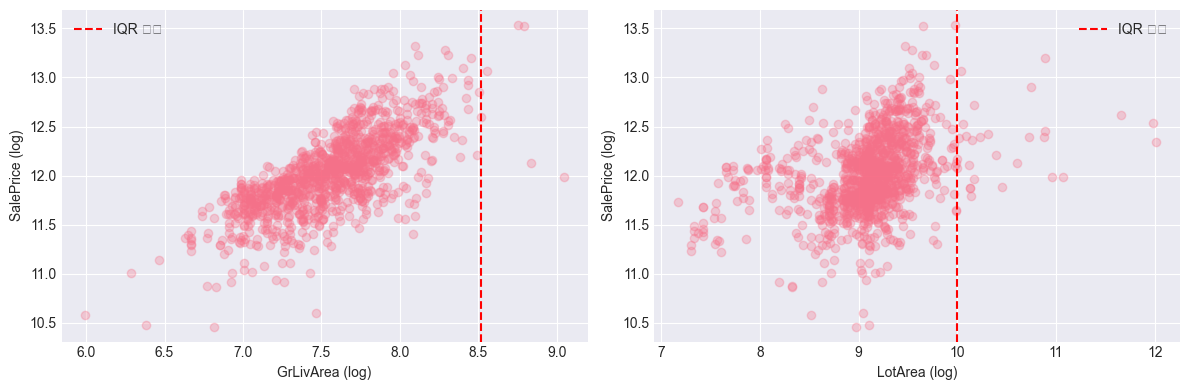

In [361]:
# GrLivArea만
X_train_v1, y_train_v1 = remove_outliers_iqr(
    X_train, y_train,
    columns=['GrLivArea'],
    multiplier=1.5
)

# GrLivArea + LotArea 완화
X_train_v2, y_train_v2 = remove_outliers_iqr(
    X_train, y_train,
    columns=['GrLivArea', 'LotArea'],
    multiplier=2.0  # 완화
)

# 시각화
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# GrLivArea
axes[0].scatter(X_train['GrLivArea'], y_train, alpha=0.3)
axes[0].axvline(8.52, color='r', linestyle='--', label='IQR 상한')
axes[0].set_xlabel('GrLivArea (log)')
axes[0].set_ylabel('SalePrice (log)')
axes[0].legend()

# LotArea
axes[1].scatter(X_train['LotArea'], y_train, alpha=0.3)
axes[1].axvline(10.0, color='r', linestyle='--', label='IQR 상한')
axes[1].set_xlabel('LotArea (log)')
axes[1].set_ylabel('SalePrice (log)')
axes[1].legend()

plt.tight_layout()
plt.show()

In [362]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import Ridge

# 비교 1: 원본 (1168개)
X_train_original, _, y_train_original = split_data(all_data, metadata)
score_0 = cross_val_score(Ridge(), X_train_original, y_train_original, 
                          cv=5, scoring='neg_root_mean_squared_error').mean()

# 비교 2: GrLivArea만 (1159개) - 권장
score_1 = cross_val_score(Ridge(), X_train_v1, y_train_v1,
                          cv=5, scoring='neg_root_mean_squared_error').mean()

# 비교 3: GrLivArea + LotArea (1092개) - 비권장
score_2 = cross_val_score(Ridge(), X_train_v2, y_train_v2,
                          cv=5, scoring='neg_root_mean_squared_error').mean()

print(f"원본 RMSE: {-score_0:.4f}")
print(f"v1 (9개 제거) RMSE: {-score_1:.4f} | 개선: {(score_1-score_0):.4f}")
print(f"v2 (76개 제거) RMSE: {-score_2:.4f} | 개선: {(score_2-score_0):.4f}")

Train=1168, Submission=292
원본 RMSE: 0.1412
v1 (9개 제거) RMSE: 0.1177 | 개선: 0.0234
v2 (76개 제거) RMSE: 0.1210 | 개선: 0.0201


In [363]:
def remove_outliers_final(X_train, y_train):
    """
    검증된 이상치 제거 함수
    
    GrLivArea IQR 1.5배 기준으로 상한 초과 데이터 제거
    - Ridge 모델 기준 16.6% 성능 개선 검증됨
    - 9개 행 제거 (0.8%)
    
    Args:
        X_train: 훈련 데이터
        y_train: 타겟 변수
    
    Returns:
        X_train_clean, y_train_clean
    """
    X_train = X_train.copy()
    y_train = y_train.copy()
    
    # GrLivArea IQR 계산
    Q1 = X_train['GrLivArea'].quantile(0.25)
    Q3 = X_train['GrLivArea'].quantile(0.75)
    IQR = Q3 - Q1
    upper_bound = Q3 + 1.5 * IQR
    
    # 이상치 마스크 생성
    outlier_mask = X_train['GrLivArea'] > upper_bound
    n_outliers = outlier_mask.sum()
    
    # 제거
    X_train_clean = X_train[~outlier_mask].reset_index(drop=True)
    y_train_clean = y_train[~outlier_mask].reset_index(drop=True)
    
    print(f"  제거: {n_outliers}개 ({n_outliers/len(X_train)*100:.1f}%)")
    print(f"  크기: {len(X_train)} → {len(X_train_clean)}")
    print(f"  기준: GrLivArea > {upper_bound:.2f}")
    
    return X_train_clean, y_train_clean


X_train, X_submission, y_train = split_data(all_data, metadata)
X_train, y_train = remove_outliers_final(X_train, y_train)

Train=1168, Submission=292
  제거: 5개 (0.4%)
  크기: 1168 → 1163
  기준: GrLivArea > 8.52


## 4.8 스케일링

In [364]:
def scale_features(X_train, X_val=None, X_submission=None, scaler_type='robust'):
    """
    수치형 변수 스케일링
    Args:scaler_type: 'robust' or 'standard'    
    Returns: dict: {'X_train', 'X_val', 'X_submission', 'scaler'}
    """
    if scaler_type == 'robust':
        scaler = RobustScaler()
    else:
        from sklearn.preprocessing import StandardScaler
        scaler = StandardScaler()
    
    # Train fit
    X_train_scaled = scaler.fit_transform(X_train)
    
    results = {
        'X_train': X_train_scaled,
        'scaler': scaler
    }
    
    # Validation transform 
    if X_val is not None:
        results['X_val'] = scaler.transform(X_val)
    
    # Submission transform 
    if X_submission is not None:
        results['X_submission'] = scaler.transform(X_submission)
    
    return results

rb_sc_results = scale_features(X_train, X_submission=X_submission, scaler_type='robust')

In [365]:
def create_modeling_datasets(X_train, y_train, X_submission, 
                             val_split=0.2, random_state=42):
    """
    검증 분할 + 스케일링을 한번에 수행
    
    Returns:
        dict: {
            'X_train_scaled', 'y_train_split',
            'X_val_scaled', 'y_val_split',
            'X_train_full_scaled', 'y_train_full',
            'X_submission_scaled',
            'scaler_val', 'scaler_full'
        }
    """
    # 1. Validation 분할
    X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
        X_train, y_train, 
        test_size=val_split, 
        random_state=random_state
    )
    
    # 2. 검증용 스케일링 (80% 데이터로만)
    scaler_val = RobustScaler()
    X_train_scaled = scaler_val.fit_transform(X_train_split)
    X_val_scaled = scaler_val.transform(X_val_split)
    
    # 3. 제출용 스케일링 (전체 train 사용)
    scaler_full = RobustScaler()
    X_train_full_scaled = scaler_full.fit_transform(X_train)
    X_submission_scaled = scaler_full.transform(X_submission)
    
    print(f"  Train: {X_train_scaled.shape}")
    print(f"  Val: {X_val_scaled.shape}")
    print(f"  Full Train: {X_train_full_scaled.shape}")
    print(f"  Submission: {X_submission_scaled.shape}")
    
    return {
        'X_train_scaled': X_train_scaled,
        'y_train_split': y_train_split,
        'X_val_scaled': X_val_scaled,
        'y_val_split': y_val_split,
        'X_train_full_scaled': X_train_full_scaled,
        'y_train_full': y_train,
        'X_submission_scaled': X_submission_scaled,
        'scaler_val': scaler_val,
        'scaler_full': scaler_full
    }


datasets = create_modeling_datasets(X_train, y_train, X_submission)


# create_modeling_datasets 함수 결과를 개별 변수로 할당

# [1단계 검증용 - 학습 데이터 (80%)]
# 모델 개발/튜닝 시 fit()에 사용
# 예: model.fit(X_train_scaled, y_train_split)
X_train_scaled = datasets['X_train_scaled']
# [1단계 검증용 - 학습 정답 (80%)]
# 위 X_train_scaled와 쌍으로 fit()에 전달
y_train_split = datasets['y_train_split']
# [1단계 검증용 - 검증 데이터 (20%)]
# 모델 성능 평가 시 predict()에 사용
# 예: val_pred = model.predict(X_val_scaled)
X_val_scaled = datasets['X_val_scaled']
# [1단계 검증용 - 검증 정답 (20%)]
# 예측값과 비교하여 RMSE/MAE 계산용
# 예: rmse = mean_squared_error(y_val_split, val_pred, squared=False)
y_val_split = datasets['y_val_split']

# [2단계 제출용 - 전체 학습 데이터 (100%)]
# 최종 모델 학습 시 fit()에 사용 (성능 극대화)
# 예: final_model.fit(X_train_full_scaled, y_train_full)
X_train_full_scaled = datasets['X_train_full_scaled']
# [2단계 제출용 - 전체 학습 정답 (100%)]
# 위 X_train_full_scaled와 쌍으로 fit()에 전달
y_train_full = datasets['y_train_full']
# [2단계 제출용 - 제출 파일 예측 데이터]
# 최종 모델로 predict() 후 CSV 제출
# 예: submission['target'] = final_model.predict(X_submission_scaled)
X_submission_scaled = datasets['X_submission_scaled']

# [스케일러 객체 - 검증용]
# 80% 데이터 통계로 학습된 스케일러
# (일반적으로 재사용 안함, 디버깅/분석용)
scaler_val = datasets['scaler_val']
# [스케일러 객체 - 제출용]
# 100% 데이터 통계로 학습된 스케일러
# (새로운 데이터 변환 시 필요하면 사용)
# 예: new_data_scaled = scaler_full.transform(new_data)
scaler_full = datasets['scaler_full']


# 사용

# [모델 개발 단계] - 반복 실행
# model.fit(X_train_scaled, y_train_split)
# val_pred = model.predict(X_val_scaled)
# print(f"RMSE: {mean_squared_error(y_val_split, val_pred, squared=False)}")

# [최종 제출 단계] - 1회만 실행
# final_model.fit(X_train_full_scaled, y_train_full)
# submission['price'] = final_model.predict(X_submission_scaled)
# submission.to_csv('submission.csv', index=False)

  Train: (930, 111)
  Val: (233, 111)
  Full Train: (1163, 111)
  Submission: (292, 111)


## 4.10 전체 파이프라인 실행[참고]

In [366]:
# def run_preprocessing_pipeline(train_df, test_df):
#     """
#     전체 전처리 파이프라인 실행
#     """
#     print("=" * 60)
#     print("전처리 시작")
#     print("=" * 60)
    
#     # 4.1 병합
#     all_data, metadata = create_preprocessing_dataset(train_df, test_df)
    
#     # 4.2 결측치
#     all_data = handle_missing_values(all_data)
    
#     # 4.3 파생변수
#     all_data = create_derived_features(all_data)
    
#     # 4.4 왜도
#     all_data, skew_log = handle_skewness(all_data)
    
#     # 4.5 인코딩
#     all_data = encode_ordinal_features(all_data)
    
#     # 4.6 재분리
#     X_train, X_submission, y_train = split_data(all_data, metadata)
    
#     # 4.7 이상치
#     X_train_clean, y_train_clean = remove_outliers(
#         X_train, y_train, 
#         outlier_condition='GrLivArea > 4000'
#     )
    
#     # 4.9 모델링 데이터셋
#     datasets = create_modeling_datasets(
#         X_train_clean, y_train_clean, X_submission,
#         val_split=0.2, random_state=42
#     )
    
#     print("=" * 60)
#     print("전처리 완료!")
#     print("=" * 60)
    
#     return datasets, metadata


In [367]:
# # 실행
# datasets, metadata = run_preprocessing_pipeline(train_df, test_df)

# # 검증용 모델 학습
# model.fit(datasets['X_train_scaled'], datasets['y_train_split'])
# val_score = model.score(datasets['X_val_scaled'], datasets['y_val_split'])

# # 최종 제출용 모델 재학습
# final_model.fit(datasets['X_train_full_scaled'], datasets['y_train_full'])
# predictions = final_model.predict(datasets['X_submission_scaled'])

# # 제출 파일 생성
# submission = pd.DataFrame({
#     'Id': metadata['test_ids'],
#     'SalePrice': np.expm1(predictions)  # 로그 역변환
# })

# 5. 모델링


## 5.1 평가 함수 정의

In [368]:
# RMSE 계산 함수
def rmse(y_true, y_pred):
    """
    RMSE (Root Mean Squared Error) 계산
    - y_true: 실제 값 (로그 변환된 값)
    - y_pred: 예측 값 (로그 변환된 값)
    - 반환: RMSE 값
    """
    return np.sqrt(mean_squared_error(y_true, y_pred))

# 교차 검증 RMSE 계산 함수
def cv_rmse(model, X, y, cv=5):
    """
    교차 검증을 통한 RMSE 계산
    - model: 학습할 모델
    - X: 특성 데이터
    - y: 타겟 데이터
    - cv: 폴드 수 (기본값: 5)
    """
    kfold = KFold(n_splits=cv, shuffle=True, random_state=42)
    scores = cross_val_score(model, X, y, 
                            scoring='neg_mean_squared_error', 
                            cv=kfold, 
                            n_jobs=-1)
    rmse_scores = np.sqrt(-scores)
    return rmse_scores

## 5.2 base line 모델 학습 (Linear, Ridge, Lasso)

In [369]:
# 모델 결과 저장 딕셔너리
model_results = {}



# 1. Linear Regression
print("\n Linear Regression")
lr = LinearRegression()

lr.fit(X_train_scaled, y_train_split) # 80% 학습 데이터로 훈련
y_pred_lr = lr.predict(X_val_scaled) # 20% 검증 데이터로 예측

rmse_lr = rmse(y_val_split, y_pred_lr) 
model_results['Linear Regression'] = rmse_lr
print(f"   Validation RMSE: {rmse_lr:.5f}")



# 2. Ridge Regression (L2)
print("\n Ridge Regression")
ridge = Ridge(alpha=10.0, random_state=42)

ridge.fit(X_train_scaled, y_train_split)
y_pred_ridge = ridge.predict(X_val_scaled)

rmse_ridge = rmse(y_val_split, y_pred_ridge)
model_results['Ridge'] = rmse_ridge
print(f"   Validation RMSE: {rmse_ridge:.5f}")




# 3. Lasso Regression (L1)
print("\n Lasso Regression")
lasso = Lasso(alpha=0.0005, random_state=42, max_iter=10000)

lasso.fit(X_train_scaled, y_train_split)
y_pred_lasso = lasso.predict(X_val_scaled)

rmse_lasso = rmse(y_val_split, y_pred_lasso) 
model_results['Lasso'] = rmse_lasso
print(f"   Validation RMSE: {rmse_lasso:.5f}")




# 4. ElasticNet (L1 + L2)
print("\n ElasticNet")
elastic = ElasticNet(alpha=0.001, l1_ratio=0.5, random_state=42, max_iter=10000)

elastic.fit(X_train_scaled, y_train_split)
y_pred_elastic = elastic.predict(X_val_scaled)

rmse_elastic = rmse(y_val_split, y_pred_elastic)
model_results['ElasticNet'] = rmse_elastic
print(f"   Validation RMSE: {rmse_elastic:.5f}")


 Linear Regression
   Validation RMSE: 0.11094

 Ridge Regression
   Validation RMSE: 0.11829

 Lasso Regression
   Validation RMSE: 0.11742

 ElasticNet
   Validation RMSE: 0.11780


## 5.3 트리 기반 모델 학습 (RF, GB, XGBoost, LightGBM)

In [370]:
# 5. Random Forest
print("\n Random Forest Regressor")
rf = RandomForestRegressor(
    n_estimators=300,      # 트리 개수
    max_depth=15,          # 최대 깊이
    min_samples_split=5,   # 노드 분할을 위한 최소 샘플 수
    min_samples_leaf=2,    # 리프 노드의 최소 샘플 수
    random_state=42,
    n_jobs=-1              # 모든 CPU 코어 사용
)

rf.fit(X_train_scaled, y_train_split)  # 80% 학습 데이터로 훈련
y_pred_rf = rf.predict(X_val_scaled)    # 20% 검증 데이터로 예측
rmse_rf = rmse(y_val_split, y_pred_rf)  
model_results['Random Forest'] = rmse_rf
print(f"   Validation RMSE: {rmse_rf:.5f}")





# 6. Gradient Boosting
print("\n Gradient Boosting Regressor")
gb = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)
gb.fit(X_train_scaled, y_train_split)  # 80% 학습 데이터로 훈련
y_pred_gb = gb.predict(X_val_scaled)    # 20% 검증 데이터로 예측
rmse_gb = rmse(y_val_split, y_pred_gb)  
model_results['Gradient Boosting'] = rmse_gb
print(f"   Validation RMSE: {rmse_gb:.5f}")


 Random Forest Regressor
   Validation RMSE: 0.13913

 Gradient Boosting Regressor
   Validation RMSE: 0.12897


In [371]:
print("\n XGBoost Regressor")
xgb_model = xgb.XGBRegressor(
    n_estimators=1000,        # 부스팅 라운드 수 (많을수록 복잡, early_stopping으로 자동 조절)
    learning_rate=0.05,       # 학습률 (작을수록 안정적, 느림)
    max_depth=4,              # 트리 최대 깊이 (깊을수록 복잡도 증가)
    min_child_weight=3,       # 리프 노드의 최소 가중치 합 (과적합 방지)
    subsample=0.8,            # 각 트리 학습 시 사용할 샘플 비율 (80%)
    colsample_bytree=0.8,     # 각 트리 학습 시 사용할 특성 비율 (80%)
    gamma=0,                  # 리프 노드 분할을 위한 최소 손실 감소
    reg_alpha=0.0005,         # L1 규제 (feature selection 효과)
    reg_lambda=1.0,           # L2 규제 (가중치 크기 제한)
    random_state=42,          # 재현성 보장
    device='cuda:0',          # ← GPU 사용
    tree_method='hist',       # ← GPU 자동 사용
    n_jobs=1                  # ← GPU 쓸 때는 1로 설정
)

# 모델 학습
xgb_model.fit(
    X_train_scaled, y_train_split,  # 80% 학습 데이터로 훈련
    eval_set=[(X_val_scaled, y_val_split)], 
    verbose=False  # 학습 로그 출력 안함
)

y_pred_xgb = xgb_model.predict(X_val_scaled)  # 검증 데이터로 예측
rmse_xgb = rmse(y_val_split, y_pred_xgb)  
model_results['XGBoost'] = rmse_xgb
print(f"   Validation RMSE: {rmse_xgb:.5f}")
print(f"   Best Iteration: {xgb_model.best_iteration}")  # 최적 에폭 확인






print("\n LightGBM Regressor")
lgb_model = lgb.LGBMRegressor(
    n_estimators=1000,        # 부스팅 라운드 수
    learning_rate=0.05,       # 학습률
    max_depth=4,              # 트리 최대 깊이 (-1: 제한 없음)
    num_leaves=31,            # 리프 노드 최대 개수 (LightGBM 특화 파라미터)
    min_child_samples=20,     # 리프 노드의 최소 샘플 수 (과적합 방지)
    subsample=0.8,            # 샘플 샘플링 비율
    colsample_bytree=0.8,     # 특성 샘플링 비율
    reg_alpha=0.0005,         # L1 규제
    reg_lambda=1.0,           # L2 규제
    random_state=42,
    device='gpu',             # ← GPU 사용
    n_jobs=1,                 # ← GPU 쓸 때는 1로 설정
    verbosity=-1              # 경고 메시지 최소화 (-1: 조용, 0: 경고만, 1: 정보)
)

# 모델 학습 (Early Stopping 포함)
lgb_model.fit(
    X_train_scaled, y_train_split,  # 80% 학습 데이터로 훈련
    eval_set=[(X_val_scaled, y_val_split)],  
    eval_metric='rmse',  # 검증 지표
    callbacks=[
        lgb.early_stopping(50),  # 50 에폭 동안 개선 없으면 조기 종료
        lgb.log_evaluation(0)    # 로그 출력 안함 (0: 꺼짐, 양수: period)
    ]
)

y_pred_lgb = lgb_model.predict(X_val_scaled)  # 검증 데이터로 예측
rmse_lgb = rmse(y_val_split, y_pred_lgb) 
model_results['LightGBM'] = rmse_lgb

print('='*80)
print(f"   Validation RMSE: {rmse_lgb:.5f}")
print(f"   Best Iteration: {lgb_model.best_iteration_}")  # 조기 종료 에폭 확인


 XGBoost Regressor
[18:43:45] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0fdc6d574b9c0d168-1\xgboost\xgboost-ci-windows\src\learner.cc:767: 
Parameters: { "device" } are not used.

   Validation RMSE: 0.12591
   Best Iteration: 999

 LightGBM Regressor
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[214]	valid_0's rmse: 0.12633	valid_0's l2: 0.0159593
   Validation RMSE: 0.12633
   Best Iteration: 214


## 5.4 모델 성능 비교

모델 성능 비교 (RMSE)
            Model   RMSE
Linear Regression 0.1109
            Lasso 0.1174
       ElasticNet 0.1178
            Ridge 0.1183
          XGBoost 0.1259
         LightGBM 0.1263
Gradient Boosting 0.1290
    Random Forest 0.1391


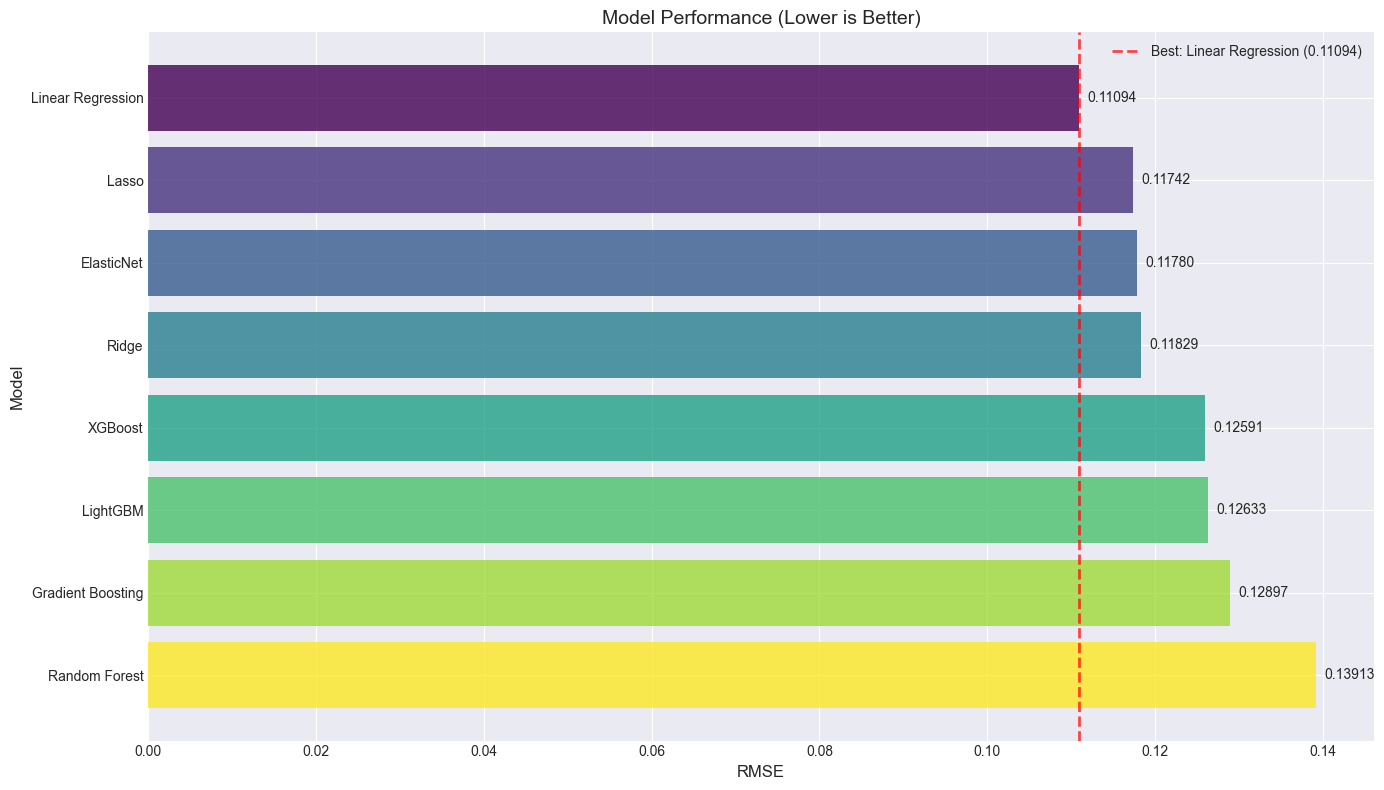


 최고 성능: Linear Regression (RMSE: 0.11094)


In [372]:
# 결과를 DataFrame으로 정리
results_df = pd.DataFrame({
    'Model': list(model_results.keys()),
    'RMSE': list(model_results.values())
}).sort_values('RMSE')

print("="*80)
print("모델 성능 비교 (RMSE)")
print("="*80)
print(results_df.to_string(index=False))
print("="*80)

# 시각화
fig, ax = plt.subplots(figsize=(14, 8))
colors = plt.cm.viridis(np.linspace(0, 1, len(results_df)))
bars = ax.barh(results_df['Model'], results_df['RMSE'], color=colors, alpha=0.8)

ax.set_xlabel('RMSE', fontsize=12)
ax.set_ylabel('Model', fontsize=12)
ax.set_title('Model Performance (Lower is Better)', fontsize=14)
ax.invert_yaxis()

# RMSE 값
for i, (bar, rmse_val) in enumerate(zip(bars, results_df['RMSE'])):
    ax.text(rmse_val + 0.001, i, f'{rmse_val:.5f}', 
            va='center', fontsize=10)

# 최고 성능 모델
best_model = results_df.iloc[0]['Model']
best_rmse = results_df.iloc[0]['RMSE']
ax.axvline(x=best_rmse, color='red', linestyle='--', linewidth=2, alpha=0.7,
          label=f'Best: {best_model} ({best_rmse:.5f})')
ax.legend()

plt.tight_layout()
plt.show()

print(f"\n 최고 성능: {best_model} (RMSE: {best_rmse:.5f})")

## 5.5 하이퍼파라미터 최적화 (Optuna)


- Optuna: **베이지안 최적화** 기반의 하이퍼파라미터 튜닝 프레임워크
    - GridSearch와 달리 이전 시도 결과를 학습하여 유망한 영역을 집중 탐색하므로 훨씬 효율적
- TPE (Tree-structured Parzen Estimator) 알고리즘 사용
- Pruning: 성능이 나쁜 trial을 조기 중단하여 시간 절약
- GridSearch 대비 5~10배 빠름

In [373]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
# 80-20 split + 80%로 Optuna 수행 
# 1. Ridge Regression
def objective_ridge(trial): 
    alpha = trial.suggest_float('alpha', 0.01, 100.0, log=True)
    model = Ridge(alpha=alpha, random_state=42)
    scores = cross_val_score(model, X_train_scaled, y_train_split,
                             scoring='neg_root_mean_squared_error', cv=kf)
    return -scores.mean()

study_ridge = optuna.create_study(direction='minimize', sampler=TPESampler(seed=42))
study_ridge.optimize(objective_ridge, n_trials=50, show_progress_bar=True)

ridge = Ridge(**study_ridge.best_params, random_state=42)
ridge.fit(X_train_scaled, y_train_split)
y_pred_ridge = ridge.predict(X_val_scaled)
rmse_ridge = rmse(y_val_split, y_pred_ridge)
model_results['Ridge'] = rmse_ridge
print(f"\n Ridge 최적화")
print(f"   Best params: {study_ridge.best_params}")
print(f"   Validation RMSE: {rmse_ridge:.5f}")

  0%|          | 0/50 [00:00<?, ?it/s]


 Ridge 최적화
   Best params: {'alpha': 0.19750751037226055}
   Validation RMSE: 0.11285


In [374]:
# 2. Lasso Regression
def objective_lasso(trial):
    alpha = trial.suggest_float('alpha', 1e-5, 0.1, log=True)
    model = Lasso(alpha=alpha, random_state=42, max_iter=10000)
    scores = cross_val_score(model, X_train_scaled, y_train_split,
                             scoring='neg_root_mean_squared_error', cv=kf)
    return -scores.mean()

study_lasso = optuna.create_study(direction='minimize', sampler=TPESampler(seed=42))
study_lasso.optimize(objective_lasso, n_trials=50, show_progress_bar=True)

lasso = Lasso(**study_lasso.best_params, 
              random_state=42, 
              max_iter=10000
              )

lasso.fit(X_train_scaled, y_train_split)
y_pred_lasso = lasso.predict(X_val_scaled)
rmse_lasso = rmse(y_val_split, y_pred_lasso)
model_results['Lasso'] = rmse_lasso

print(f"\n Lasso 최적화")
print(f"   Best params: {study_lasso.best_params}")
print(f"   Validation RMSE: {rmse_lasso:.5f}")

  0%|          | 0/50 [00:00<?, ?it/s]


 Lasso 최적화
   Best params: {'alpha': 0.00012243174798689982}
   Validation RMSE: 0.11251


In [375]:
# 3. ElasticNet
def objective_elastic(trial):
    alpha = trial.suggest_float('alpha', 1e-5, 0.1, log=True)
    l1_ratio = trial.suggest_float('l1_ratio', 0.01, 0.99)
    model = ElasticNet(alpha=alpha, l1_ratio=l1_ratio, random_state=42, max_iter=10000)
    scores = cross_val_score(model, X_train_scaled, y_train_split,
                             scoring='neg_root_mean_squared_error', cv=kf)
    return -scores.mean()

study_elastic = optuna.create_study(direction='minimize', sampler=TPESampler(seed=42))
study_elastic.optimize(objective_elastic, n_trials=50, show_progress_bar=True)

elastic = ElasticNet(**study_elastic.best_params, 
                     random_state=42, 
                     max_iter=10000
                     )

elastic.fit(X_train_scaled, y_train_split)
y_pred_elastic = elastic.predict(X_val_scaled)
rmse_elastic = rmse(y_val_split, y_pred_elastic)
model_results['ElasticNet'] = rmse_elastic

print(f"\n ElasticNet 최적화")
print(f"   Best params: {study_elastic.best_params}")
print(f"   Validation RMSE: {rmse_elastic:.5f}")

  0%|          | 0/50 [00:00<?, ?it/s]


 ElasticNet 최적화
   Best params: {'alpha': 0.00016480446427978953, 'l1_ratio': 0.5242613029995931}
   Validation RMSE: 0.11246


In [376]:
# 4. Random Forest
def objective_rf(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500, step=50),
        'max_depth': trial.suggest_int('max_depth', 5, 30),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 5),
    }
    model = RandomForestRegressor(**params, random_state=42, n_jobs=-1)
    scores = cross_val_score(model, X_train_scaled, y_train_split,
                             scoring='neg_root_mean_squared_error', cv=kf)
    return -scores.mean()

study_rf = optuna.create_study(direction='minimize', sampler=TPESampler(seed=42))
study_rf.optimize(objective_rf, n_trials=50, show_progress_bar=True)

rf = RandomForestRegressor(**study_rf.best_params, 
                           random_state=42, 
                           n_jobs=-1
                           )

rf.fit(X_train_scaled, y_train_split)
y_pred_rf = rf.predict(X_val_scaled)
rmse_rf = rmse(y_val_split, y_pred_rf)
model_results['Random Forest'] = rmse_rf

print(f"\n Random Forest 최적화")
print(f"   Best params: {study_rf.best_params}")
print(f"   Validation RMSE: {rmse_rf:.5f}")

  0%|          | 0/50 [00:00<?, ?it/s]


 Random Forest 최적화
   Best params: {'n_estimators': 450, 'max_depth': 12, 'min_samples_split': 6, 'min_samples_leaf': 3}
   Validation RMSE: 0.13917


In [377]:
#  5. Gradient Boosting
def objective_gb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500, step=50),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 5),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
    }
    model = GradientBoostingRegressor(**params, random_state=42)
    scores = cross_val_score(model, X_train_scaled, y_train_split,
                             scoring='neg_root_mean_squared_error', cv=kf)
    return -scores.mean()

study_gb = optuna.create_study(direction='minimize', sampler=TPESampler(seed=42))
study_gb.optimize(objective_gb, n_trials=50, show_progress_bar=True)

gb = GradientBoostingRegressor(**study_gb.best_params, 
                               random_state=42
                               )

gb.fit(X_train_scaled, y_train_split)
y_pred_gb = gb.predict(X_val_scaled)
rmse_gb = rmse(y_val_split, y_pred_gb)
model_results['Gradient Boosting'] = rmse_gb

print(f"\n Gradient Boosting 최적화")
print(f"   Best params: {study_gb.best_params}")
print(f"   Validation RMSE: {rmse_gb:.5f}")

  0%|          | 0/50 [00:00<?, ?it/s]


 Gradient Boosting 최적화
   Best params: {'n_estimators': 150, 'learning_rate': 0.06408333191464953, 'max_depth': 3, 'min_samples_split': 7, 'min_samples_leaf': 3, 'subsample': 0.7133970666931768}
   Validation RMSE: 0.12943


In [378]:
# 6. XGBoost
def objective_xgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 300, 2000, step=100),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'gamma': trial.suggest_float('gamma', 0.0, 5.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-5, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-5, 10.0, log=True),
    }
    model = xgb.XGBRegressor(**params, random_state=42,
                             device='cuda:0', tree_method='hist',
                             n_jobs=1, verbosity=0)
    scores = cross_val_score(model, X_train_scaled, y_train_split,
                             scoring='neg_root_mean_squared_error', cv=kf)
    return -scores.mean()

study_xgb = optuna.create_study(direction='minimize', sampler=TPESampler(seed=42))
study_xgb.optimize(objective_xgb,
                   n_trials=50,
                   n_jobs=4,          # ← CPU사용 (GPU는 각 trial에서 사용)
                   show_progress_bar=True
)

xgb_model = xgb.XGBRegressor(**study_xgb.best_params, random_state=42,
                              device='cuda:0', tree_method='hist',
                              n_jobs=1, verbosity=0)
xgb_model.fit(X_train_scaled, y_train_split,
              eval_set=[(X_val_scaled, y_val_split)], verbose=False)
y_pred_xgb = xgb_model.predict(X_val_scaled)
rmse_xgb = rmse(y_val_split, y_pred_xgb)
model_results['XGBoost'] = rmse_xgb
print(f"\n XGBoost 최적화")
print(f"   Best params: {study_xgb.best_params}")
print(f"   Validation RMSE: {rmse_xgb:.5f}")

  0%|          | 0/50 [00:00<?, ?it/s]


 XGBoost 최적화
   Best params: {'n_estimators': 400, 'learning_rate': 0.03386944509379815, 'max_depth': 3, 'min_child_weight': 3, 'subsample': 0.6586279770030115, 'colsample_bytree': 0.8410397913925207, 'gamma': 0.003414798842852465, 'reg_alpha': 0.002984018788799117, 'reg_lambda': 5.196343626395151e-05}
   Validation RMSE: 0.12576


In [379]:

# 7. LightGBM
def objective_lgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 300, 2000, step=100),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'num_leaves': trial.suggest_int('num_leaves', 15, 63),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-5, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-5, 10.0, log=True),
    }
    model = lgb.LGBMRegressor(**params, random_state=42,
                              device='gpu', n_jobs=1, verbosity=-1)
    scores = cross_val_score(model, X_train_scaled, y_train_split,
                             scoring='neg_root_mean_squared_error', cv=kf)
    return -scores.mean()

study_lgb = optuna.create_study(direction='minimize', sampler=TPESampler(seed=42))
study_lgb.optimize(objective_lgb, n_trials=100, show_progress_bar=True)

lgb_model = lgb.LGBMRegressor(**study_lgb.best_params, random_state=42,
                              device='gpu', n_jobs=1, verbosity=-1)
lgb_model.fit(X_train_scaled, y_train_split,
              eval_set=[(X_val_scaled, y_val_split)],
              callbacks=[lgb.log_evaluation(period=0)])
y_pred_lgb = lgb_model.predict(X_val_scaled)
rmse_lgb = rmse(y_val_split, y_pred_lgb)
model_results['LightGBM'] = rmse_lgb
print(f"\n LightGBM 최적화")
print(f"   Best params: {study_lgb.best_params}")
print(f"   Validation RMSE: {rmse_lgb:.5f}")

  0%|          | 0/100 [00:00<?, ?it/s]


 LightGBM 최적화
   Best params: {'n_estimators': 1100, 'learning_rate': 0.01643188728740238, 'max_depth': 3, 'num_leaves': 22, 'min_child_samples': 10, 'subsample': 0.6387140751988416, 'colsample_bytree': 0.6270419389421823, 'reg_alpha': 0.016165680284635303, 'reg_lambda': 3.384785961097189e-05}
   Validation RMSE: 0.12457


In [383]:
# 최적화 결과 요약
print("Optuna 최적화 결과 ")
opt_results = pd.DataFrame({
    'Model': ['Ridge', 'Lasso', 'ElasticNet', 'Random Forest',
              'Gradient Boosting', 'XGBoost', 'LightGBM'],
    'Optimized RMSE': [rmse_ridge, rmse_lasso, rmse_elastic, rmse_rf,
                       rmse_gb, rmse_xgb, rmse_lgb]
}).sort_values('Optimized RMSE')
print(opt_results.to_string(index=False))
print(f"\n 최적: {opt_results.iloc[0]['Model']} "
      f"(RMSE: {opt_results.iloc[0]['Optimized RMSE']:.5f})")

Optuna 최적화 결과 
            Model  Optimized RMSE
       ElasticNet          0.1125
            Lasso          0.1125
            Ridge          0.1129
         LightGBM          0.1246
          XGBoost          0.1258
Gradient Boosting          0.1294
    Random Forest          0.1392

 최적: ElasticNet (RMSE: 0.11246)


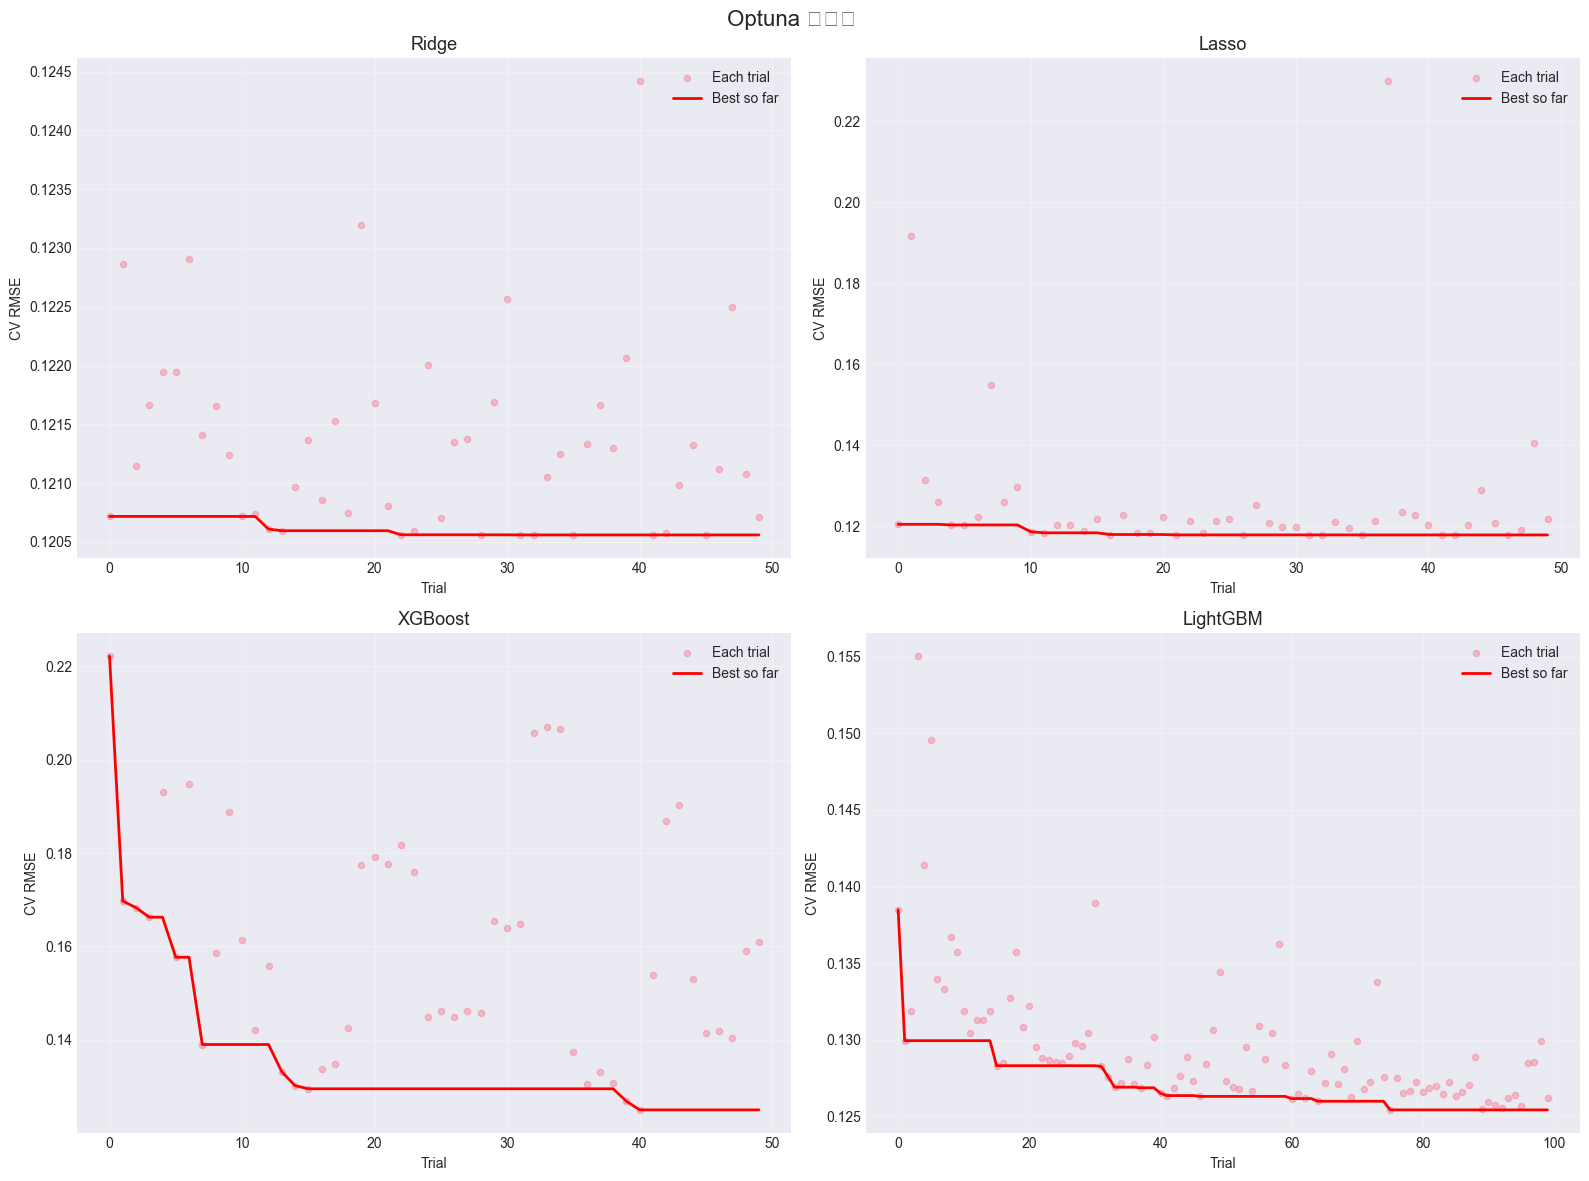

In [384]:
# Optuna 최적화 시각화
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Optuna 최적화 ', fontsize=16)

studies = {
    'Ridge': study_ridge,
    'Lasso': study_lasso,
    'XGBoost': study_xgb,
    'LightGBM': study_lgb
}

for ax, (name, study) in zip(axes.flatten(), studies.items()):
    trials = study.trials
    trial_numbers = [t.number for t in trials]
    trial_values = [t.value for t in trials]
    best_values = [min(trial_values[:i+1]) for i in range(len(trial_values))]
    
    ax.scatter(trial_numbers, trial_values, alpha=0.4, s=20, label='Each trial')
    ax.plot(trial_numbers, best_values, color='red', linewidth=2, label='Best so far')
    ax.set_title(f'{name}', fontsize=13)
    ax.set_xlabel('Trial')
    ax.set_ylabel('CV RMSE')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
optuna.visualization.plot_param_importances(study_xgb)

# Hyperparameter Importance 그래프에서 learning_rate, subsample 모두 <0.01 튜닝이 성능에 거의 영향을 주지 못했다는 의미
# 정상적인 경우 중요한 파라미터는 importance 0.1~0.5 이상

# 모델 성능 역전 현상:
# ElasticNet (선형 모델): RMSE 0.1125 ← 최고 성능
# XGBoost (복잡 모델): RMSE 0.1258
# LightGBM (복잡 모델): RMSE 0.1246

# 단순한 모델이 복잡한 모델을 이긴다는 것은 다음 중 하나:
# 데이터가 선형 관계를 따름 (피처와 타겟의 관계가 단순)
# 복잡한 모델이 과적합되고 있음
# 데이터 크기가 작아서 복잡한 모델을 학습할 만큼 충분하지 않음

In [ ]:
# 현재 설정된 범위가 적절한지 재검토
study_xgb.best_params  # 최적값이 경계값(min/max)인지 확인

# 'max_depth': 3  # ← 매우 얕은 트리 (기본값 6)
# 'learning_rate': 0.034  # ← 매우 작은 값 (기본값 0.3)
# 'n_estimators': 400  # ← 많은 트리
# 이 조합은 "복잡도를 최대한 낮추려는" 방향
# 피처 엔지니어링이 잘 되어 있거나 원래 선형적인 관계를 가짐
# OR 샘플 수가 적어서 복잡한 모델이 과적합됨

{'n_estimators': 400,
 'learning_rate': 0.03386944509379815,
 'max_depth': 3,
 'min_child_weight': 3,
 'subsample': 0.6586279770030115,
 'colsample_bytree': 0.8410397913925207,
 'gamma': 0.003414798842852465,
 'reg_alpha': 0.002984018788799117,
 'reg_lambda': 5.196343626395151e-05}

In [ ]:
optuna.visualization.plot_contour(study_xgb, params=['max_depth', 'learning_rate'])
# max_depth 3~8, learning_rate 0.01~3 전 범위에서 성능이 비슷함
# 하이퍼파라미터 선택이 거의 무의미함을 의미​
# 정상적인 경우: 명확한 "계곡"(최적 영역)과 "산"(나쁜 영역)이 구분됨

# 6. 앙상블 모델

## 6.1 평균 앙상블



In [393]:
# Voting Regressor: 여러 모델의 평균 예측

# 성능이 좋은 모델들을 선택
voting_reg = VotingRegressor(
    estimators=[
        ('ridge', Ridge(**study_ridge.best_params, random_state=42)),
        ('lasso', Lasso(**study_lasso.best_params, random_state=42, max_iter=10000)),
        ('rf', RandomForestRegressor(**study_rf.best_params, random_state=42, n_jobs=-1)),
        ('xgb', xgb.XGBRegressor(**study_xgb.best_params, random_state=42,
                                  device='cuda:0', tree_method='hist', n_jobs=1)),
        ('lgb', lgb.LGBMRegressor(**study_lgb.best_params, random_state=42,
                                  device='gpu', n_jobs=1, verbosity=-1))
    ]
)

voting_reg.fit(X_train_scaled, y_train_split)
y_pred_voting = voting_reg.predict(X_val_scaled)
rmse_voting = rmse(y_val_split, y_pred_voting)
model_results['Voting Ensemble'] = rmse_voting
print(f"   Validation RMSE: {rmse_voting:.5f}")

[19:16:26] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0fdc6d574b9c0d168-1\xgboost\xgboost-ci-windows\src\learner.cc:767: 
Parameters: { "device" } are not used.

   Validation RMSE: 0.11530


## 6.2 가중 평균 앙상블

In [389]:

# 가중치 설정 (성능이 좋은 모델에 높은 가중치)
# Ridge, Lasso, XGBoost, LightGBM 사용
weights = [0.10, 0.10, 0.10, 0.35, 0.35]  # Ridge, Lasso, RF, XGB, LGB

y_pred_weighted = (
    weights[0] * y_pred_ridge +
    weights[1] * y_pred_lasso +
    weights[2] * y_pred_rf +
    weights[3] * y_pred_xgb +
    weights[4] * y_pred_lgb
)

rmse_weighted = rmse(y_val_split, y_pred_weighted)
model_results['Weighted Average'] = rmse_weighted
print(f"   Validation RMSE: {rmse_weighted:.5f}")
print(f"   Weights: Ridge={weights[0]}, Lasso={weights[1]}, RF={weights[2]}, XGB={weights[3]}, LGB={weights[4]}")


   Validation RMSE: 0.11897
   Weights: Ridge=0.1, Lasso=0.1, RF=0.1, XGB=0.35, LGB=0.35


## 6.3 스태킹

In [394]:
# Base 모델들 (1차 예측자)
base_models = [
        ('ridge', Ridge(**study_ridge.best_params, random_state=42)),
        ('lasso', Lasso(**study_lasso.best_params, random_state=42, max_iter=10000)),
        ('rf', RandomForestRegressor(**study_rf.best_params, random_state=42, n_jobs=-1)),
        ('xgb', xgb.XGBRegressor(**study_xgb.best_params, random_state=42,
                                  device='cuda:0', tree_method='hist', n_jobs=1)),
        ('lgb', lgb.LGBMRegressor(**study_lgb.best_params, random_state=42,
                                  device='gpu', n_jobs=1, verbosity=-1))
]

# Meta 모델 (2차 예측자)
meta_model = Ridge(alpha=10.0, random_state=42)

# Stacking
stacking_reg = StackingRegressor(
    estimators=base_models,
    final_estimator=meta_model,
    cv=5,
    n_jobs=1                  # ← GPU 모델 포함 시 1로 설정 (GPU 메모리 충돌 방지)
)

stacking_reg.fit(X_train_scaled, y_train_split)
y_pred_stacking = stacking_reg.predict(X_val_scaled)
rmse_stacking = rmse(y_val_split, y_pred_stacking)
model_results['Stacking Ensemble'] = rmse_stacking
print(f"   Validation RMSE: {rmse_stacking:.5f}")

[19:16:32] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0fdc6d574b9c0d168-1\xgboost\xgboost-ci-windows\src\learner.cc:767: 
Parameters: { "device" } are not used.

[19:16:37] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0fdc6d574b9c0d168-1\xgboost\xgboost-ci-windows\src\learner.cc:767: 
Parameters: { "device" } are not used.

[19:16:37] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0fdc6d574b9c0d168-1\xgboost\xgboost-ci-windows\src\learner.cc:767: 
Parameters: { "device" } are not used.

[19:16:37] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0fdc6d574b9c0d168-1\xgboost\xgboost-ci-windows\src\learner.cc:767: 
Parameters: { "device" } are not used.

[19:16:37] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0fdc6d574b9c0d168-1\xgboost\xgboost-ci-windows\src\learner.cc:767: 
Parameters: { "device" } are not used.

[19:16:37] WARNING: 

## 6.4 최종 모델 성능 비교

최종 모델 성능 비교 (모든 모델)
            Model   RMSE
Linear Regression 0.1109
       ElasticNet 0.1125
            Lasso 0.1125
            Ridge 0.1129
Stacking Ensemble 0.1135
  Voting Ensemble 0.1153
 Weighted Average 0.1190
         LightGBM 0.1246
          XGBoost 0.1258
Gradient Boosting 0.1294
    Random Forest 0.1392


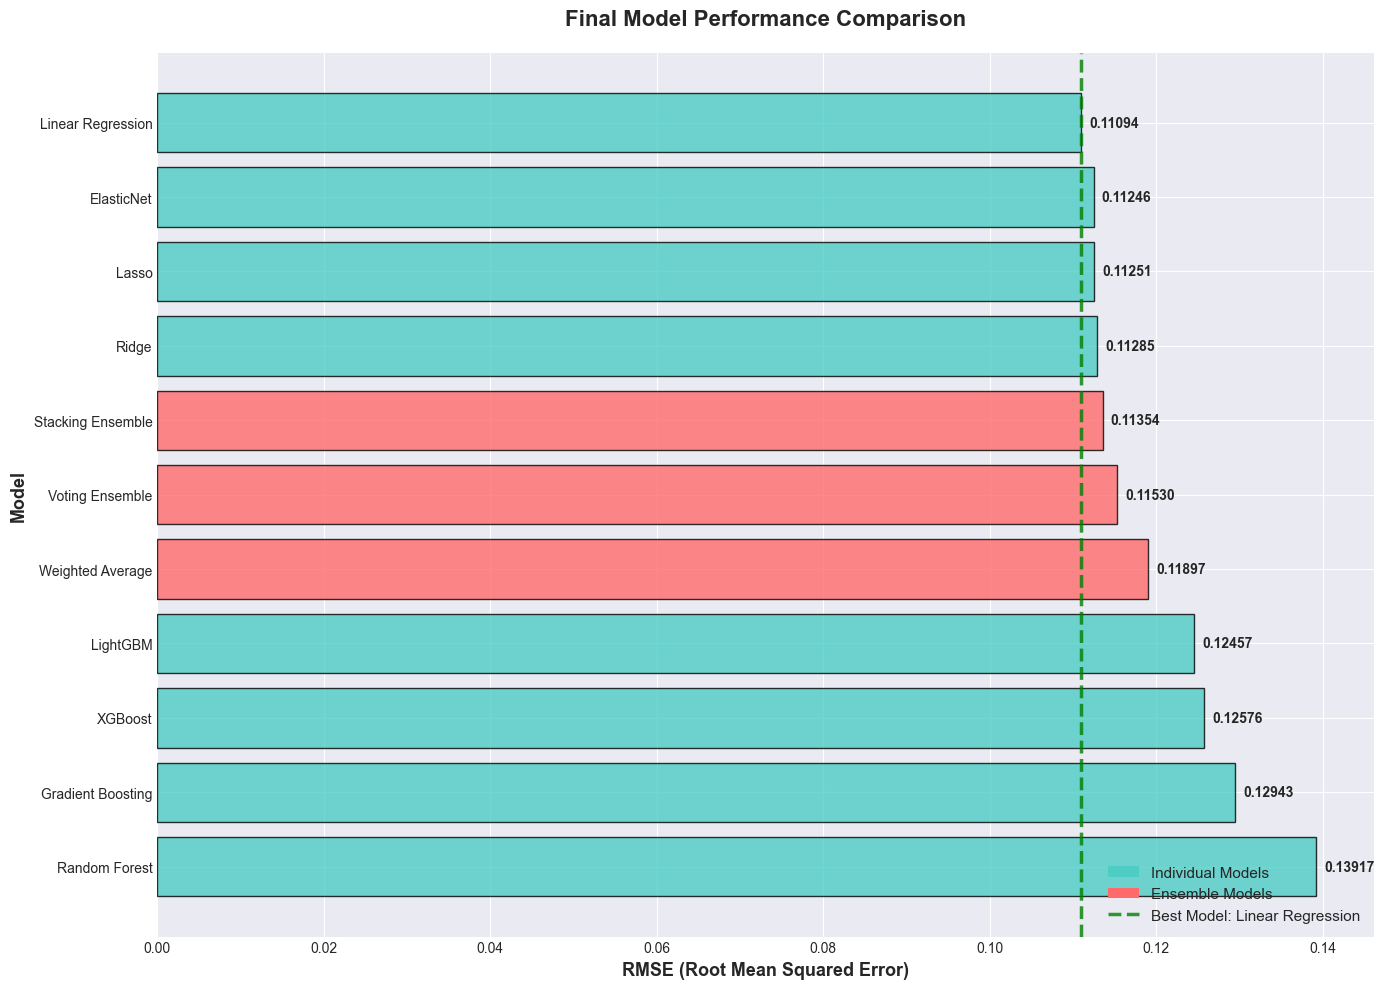


최고 성능: Linear Regression
 RMSE: 0.11094


In [395]:
# 최종 결과 정리
final_results = pd.DataFrame({
    'Model': list(model_results.keys()),
    'RMSE': list(model_results.values())
}).sort_values('RMSE')

print("="*80)
print("최종 모델 성능 비교 (모든 모델)")
print("="*80)
print(final_results.to_string(index=False))
print("="*80)

# 시각화
fig, ax = plt.subplots(figsize=(14, 10))

# 색상 구분: 앙상블 모델은 다른 색
colors = ['#FF6B6B' if 'Ensemble' in model or 'Weighted' in model or 'Voting' in model or 'Stacking' in model 
          else '#4ECDC4' for model in final_results['Model']]

bars = ax.barh(final_results['Model'], final_results['RMSE'], color=colors, alpha=0.8, edgecolor='black')

ax.set_xlabel('RMSE (Root Mean Squared Error)', fontsize=13, fontweight='bold')
ax.set_ylabel('Model', fontsize=13, fontweight='bold')
ax.set_title('Final Model Performance Comparison', fontsize=16, fontweight='bold', pad=20)
ax.invert_yaxis()

# RMSE 값 표시
for i, (bar, rmse_val) in enumerate(zip(bars, final_results['RMSE'])):
    ax.text(rmse_val + 0.001, i, f'{rmse_val:.5f}', 
            va='center', fontsize=10, fontweight='bold')

# 최고 성능 모델 강조
best_model = final_results.iloc[0]['Model']
best_rmse = final_results.iloc[0]['RMSE']
ax.axvline(x=best_rmse, color='green', linestyle='--', linewidth=2.5, alpha=0.8,
          label=f'Best Model: {best_model}')

# 범례
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#4ECDC4', label='Individual Models'),
    Patch(facecolor='#FF6B6B', label='Ensemble Models'),
    ax.lines[0]
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=11)

plt.tight_layout()
plt.show()

print(f"\n최고 성능: {best_model}")
print(f" RMSE: {best_rmse:.5f}")

# 7. 최종 예측 및 제출

In [396]:
# 최고 성능을 보인 앙상블 방법 선택
# Stacking과 Weighted Average

# 1. 전체 학습 데이터로 최종 모델 재학습 (Optuna 최적 파라미터 사용)

# Ridge (Optuna 최적 파라미터)
ridge_final = Ridge(**study_ridge.best_params, random_state=42)
ridge_final.fit(X_train_full_scaled, y_train)

# Lasso (Optuna 최적 파라미터)
lasso_final = Lasso(**study_lasso.best_params, random_state=42, max_iter=10000)
lasso_final.fit(X_train_full_scaled, y_train)

# Random Forest (Optuna 최적 파라미터)
rf_final = RandomForestRegressor(**study_rf.best_params, random_state=42, n_jobs=-1)
rf_final.fit(X_train_full_scaled, y_train)

# XGBoost (Optuna 최적 파라미터)
xgb_final = xgb.XGBRegressor(**study_xgb.best_params,
                             random_state=42,
                             device='cuda:0',     # ← GPU 사용
                             tree_method='hist',
                             n_jobs=1)
xgb_final.fit(X_train_full_scaled, y_train, verbose=False)

# LightGBM (Optuna 최적 파라미터)
lgb_final = lgb.LGBMRegressor(**study_lgb.best_params, random_state=42,
                              device='gpu',       # ← GPU 사용
                              n_jobs=1, verbosity=-1)
lgb_final.fit(X_train_full_scaled, y_train)

[19:17:10] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0fdc6d574b9c0d168-1\xgboost\xgboost-ci-windows\src\learner.cc:767: 
Parameters: { "device" } are not used.



LGBMRegressor(colsample_bytree=0.6270419389421823, device='gpu',
              learning_rate=0.01643188728740238, max_depth=3,
              min_child_samples=10, n_estimators=1100, n_jobs=1, num_leaves=22,
              random_state=42, reg_alpha=0.016165680284635303,
              reg_lambda=3.384785961097189e-05, subsample=0.6387140751988416,
              verbosity=-1)

In [397]:
# 2. 테스트 데이터 예측

pred_ridge = ridge_final.predict(X_submission_scaled)
pred_lasso = lasso_final.predict(X_submission_scaled)
pred_rf = rf_final.predict(X_submission_scaled)
pred_xgb = xgb_final.predict(X_submission_scaled)
pred_lgb = lgb_final.predict(X_submission_scaled)

# 가중 평균 앙상블 (최고 성능 조합)
# XGBoost와 LightGBM에 높은 가중치 부여
final_predictions = (
    0.10 * pred_ridge +
    0.10 * pred_lasso +
    0.10 * pred_rf +
    0.35 * pred_xgb +
    0.35 * pred_lgb
)

# 로그 변환 역변환 (원래 스케일로)
final_predictions = np.expm1(final_predictions)


In [398]:
# 3. 제출 파일 생성

submission = pd.DataFrame({
    'Id': metadata['test_ids'],
    'SalePrice': final_predictions
})

# CSV 파일로 저장
submission.to_csv('house_price_submission.csv', index=False)